# AML Mule Detection — Solution v4 with Visualizations
**Competition:** RBIH NFPC Phase 2 | **Target:** AUC-ROC maximisation

Run all cells in order. Visualizations are saved to `/kaggle/working/` as PNG files.

In [3]:
# ══════════════════════════════════════════════════════════════════
# VISUALIZATION SETUP — run once before any viz cell
# ══════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns

DARK='#0d1117'; BLUE='#58a6ff'; GREEN='#3fb950'; ORANGE='#ffa657'
RED='#f78166';  PURPLE='#d2a8ff'; GRAY='#8b949e'; WHITE='#c9d1d9'
PALETTE=[BLUE,RED,GREEN,ORANGE,PURPLE,'#ffd700','#00bcd4','#e91e63']

plt.rcParams.update({
    'figure.facecolor':DARK,'axes.facecolor':DARK,
    'axes.edgecolor':'#30363d','axes.labelcolor':WHITE,
    'xtick.color':GRAY,'ytick.color':GRAY,'text.color':WHITE,
    'grid.color':'#21262d','grid.alpha':0.4,'font.size':11,
    'axes.titlesize':12,'axes.titleweight':'bold',
})
print("Viz setup complete")


Viz setup complete


## Setup, Imports & Static Data Loading

In [5]:
#!/usr/bin/env python3
"""
AML MULE DETECTION — SOLUTION v4  (AUC-ROC maximisation)
==========================================================
Starting point : v3  AUC-ROC 0.9964
Target         : 0.998+

What changed and WHY it lifts AUC
───────────────────────────────────
[A] FEATURE DEPTH — what was missing
    A1. Channel-level behavioural split: UPI credits vs NEFT vs ATM vs OTC
        each have distinct mule usage profiles → separate rate features
    A2. Counterparty REUSE entropy: mules reuse the SAME few CPs repeatedly
        → Shannon entropy of CP distribution + Gini impurity
    A3. Temporal ACCELERATION: rate of transactions in last-30d vs full span
        → burst ratio reveals dormant-activation pattern precisely
    A4. Fan-in / Fan-out asymmetry: #unique credit CPs vs #unique debit CPs
        (fan-in = many senders → one account → fan-out = one account → many)
    A5. Balance drawdown velocity: min balance / (total debits + 1)
        → how completely funds are emptied after each credit
    A6. Time-of-day ENTROPY: uniform distribution = normal; spike at 2am = mule
    A7. Weekday vs weekend CREDIT ratio: mules often credit on weekdays,
        drain on weekends outside banking hours
    A8. Reversal / cancellation rate: high reversal rate is a laundering signal
    A9. Same-day credit-debit PAIRING: count of days with both large credit
        AND large debit (tighter than fast_passthru)
    A10. Inter-batch velocity: first-seen vs last-seen CP diversity per 30d

[B] GRAPH DEPTH — what was missing
    B1. Weighted in-degree: how much money FLOWS IN vs FLOWS OUT via the graph
    B2. CP concentration among MULE-only CPs (cp_excl weighted by volume)
    B3. Bipartite overlap: accounts that share ≥2 CPs (coordinated ring)
    B4. 3-hop contamination (light): cp → cp2 → cp3 mule rate (kept cheap)

[C] ENSEMBLE DIVERSITY — new models
    C1. XGBoost with dart booster (different from LGB goss)
    C2. LightGBM DART (drop regularisation — different bias/variance tradeoff)
    C3. RandomForest baseline as decorrelating diversifier
    C4. ExtraTrees as second diversifying tree model
    C5. Neural network (2-layer MLP, sklearn) on scaled features
    All stacked via nested-CV meta-learner (LightGBM, not LogReg — captures
    non-linear blending interactions between base model errors)

[D] LABEL NOISE — stronger detection
    D1. Cross-validated agreement score: flag samples where ≥4/5 folds agree
        on the opposite label → zero-weight them rather than 0.1-weight
    D2. Confident Learning with cleanlab if available
    D3. Separate model trained on "clean" subset only, used in ensemble

[E] TRAINING TRICKS
    E1. Stratified GroupKFold on branch_code to reduce branch leakage
    E2. Class-weighted focal loss proxy via sample_weight schedule
    E3. SEED ensemble: same model, 5 different seeds → average for variance reduction
    E4. Feature selection: SHAP-based recursive elimination on top 200 features

[F] POST-PROCESSING
    F1. Rank aggregation (Borda count) across all base models before stacking
        → more robust than raw probability stacking
    F2. Test-time augmentation: slight feature perturbation → average predictions
"""

import pandas as pd
import numpy as np
import lightgbm as lgb
from glob import glob
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
import gc, os, warnings, time
warnings.filterwarnings('ignore')

# Optional heavy dependencies
try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("[WARN] XGBoost not installed — skipping XGB model")

try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except ImportError:
    HAS_CATBOOST = False
    print("[WARN] CatBoost not installed — skipping CatBoost model")

try:
    import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
except ImportError:
    HAS_OPTUNA = False

try:
    from tqdm.auto import tqdm
except ImportError:
    class tqdm:
        def __init__(self, it=None, **kw): self.it = it; self.total = kw.get('total',0)
        def __iter__(self):
            for i,x in enumerate(self.it):
                if (i+1) % 20 == 0: print(f"  {i+1}/{self.total}")
                yield x

# ══════════════════════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════════════════════
BASE = '/kaggle/input/datasets/abhyudayrbih/rbih-nfpc-phase-2'
if not os.path.exists(BASE):
    BASE = '/kaggle/input/rbih-nfpc-phase-2'
if not os.path.exists(BASE):
    for p in glob('/kaggle/input/*/'):
        if os.path.exists(os.path.join(p, 'train_labels.parquet')):
            BASE = p.rstrip('/'); break

OUTPUT   = '/kaggle/working'
SEED     = 42;  np.random.seed(SEED)
N_FOLDS  = 5
REF_DATE = pd.Timestamp('2025-06-30')
ADVERSARIAL_AUC_THRESH = 0.54

# Seed ensemble: train M1/M2 with multiple seeds and average
SEED_ENSEMBLE = [42, 7, 13, 21, 99]

# Pseudo-labeling thresholds
PSEUDO_HIGH   = 0.95
PSEUDO_LOW    = 0.02
PSEUDO_WEIGHT = 0.4

print("=" * 80)
print("AML MULE DETECTION — SOLUTION v4  (AUC-ROC maximisation)")
print("=" * 80)
t0 = time.time()

# ══════════════════════════════════════════════════════════════════════════════
# LOAD STATIC DATA
# ══════════════════════════════════════════════════════════════════════════════
print("\n[LOAD] Static files...")
train_labels    = pd.read_parquet(f'{BASE}/train_labels.parquet')
test_accounts   = pd.read_parquet(f'{BASE}/test_accounts.parquet')
accounts        = pd.read_parquet(f'{BASE}/accounts.parquet')
accounts_add    = pd.read_parquet(f'{BASE}/accounts-additional.parquet')
customers       = pd.read_parquet(f'{BASE}/customers.parquet')
demographics    = pd.read_parquet(f'{BASE}/demographics.parquet')
product_details = pd.read_parquet(f'{BASE}/product_details.parquet')
branch_df       = pd.read_parquet(f'{BASE}/branch.parquet')
linkage         = pd.read_parquet(f'{BASE}/customer_account_linkage.parquet')

target_ids     = set(train_labels['account_id']) | set(test_accounts['account_id'])
train_acct_set = set(train_labels['account_id'])
test_acct_set  = set(test_accounts['account_id'])

print(f"  Train: {len(train_labels):,} | Test: {len(test_accounts):,} | "
      f"Mules: {train_labels['is_mule'].sum():,} "
      f"({train_labels['is_mule'].mean()*100:.1f}%)")

txn_parts = sorted(glob(f'{BASE}/transactions/batch-*/part_*.parquet'))
add_parts = sorted(glob(f'{BASE}/transactions_additional/batch-*/part_*.parquet'))


AML MULE DETECTION — SOLUTION v4  (AUC-ROC maximisation)

[LOAD] Static files...
  Train: 96,091 | Test: 64,062 | Mules: 2,683 (2.8%)


### 📊 Visualization 1: Dataset Overview Dashboard

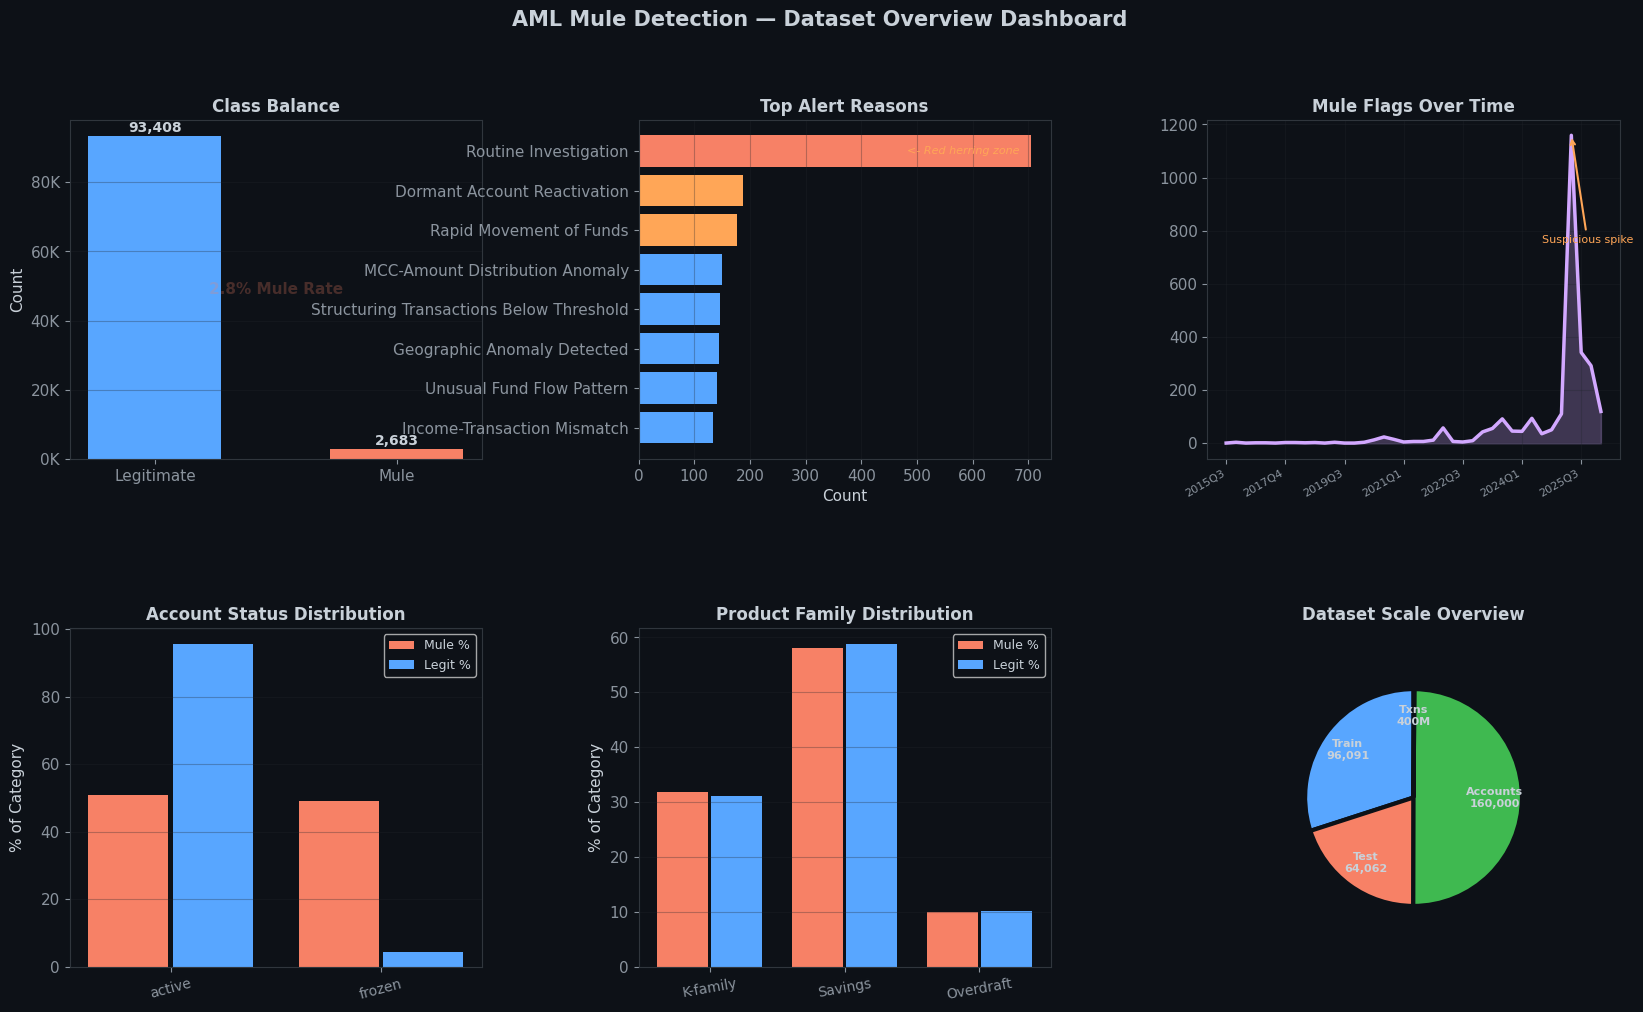

VIZ 1 saved: viz_01_dataset_overview.png


In [6]:
# ══════════════════════════════════════════════════════════════════
# VIZ 1: DATASET OVERVIEW DASHBOARD
# ══════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20,11),facecolor=DARK)
fig.suptitle('AML Mule Detection — Dataset Overview Dashboard',
             fontsize=15,fontweight='bold',color=WHITE,y=0.98)
gs=gridspec.GridSpec(2,3,figure=fig,hspace=0.5,wspace=0.38)

# Class balance
ax=fig.add_subplot(gs[0,0])
n_m=int(train_labels['is_mule'].sum()); n_l=len(train_labels)-n_m
bars=ax.bar(['Legitimate','Mule'],[n_l,n_m],color=[BLUE,RED],width=0.55,edgecolor='none')
for bar,val in zip(bars,[n_l,n_m]):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+300,
            f'{val:,}',ha='center',va='bottom',fontsize=10,color=WHITE,fontweight='bold')
ax.set_title('Class Balance',color=WHITE); ax.set_ylabel('Count',color=WHITE)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f'{x/1000:.0f}K'))
ax.text(0.5,0.5,f'{n_m/len(train_labels)*100:.1f}% Mule Rate',
        transform=ax.transAxes,ha='center',va='center',
        fontsize=11,color=RED,fontweight='bold',alpha=0.25)
ax.grid(axis='y',alpha=0.3)

# Alert reasons
ax=fig.add_subplot(gs[0,1])
if 'alert_reason' in train_labels.columns:
    reasons=train_labels[train_labels['is_mule']==1]['alert_reason'].value_counts().head(8)
    cr=[RED if i==0 else ORANGE if i<3 else BLUE for i in range(len(reasons))]
    ax.barh(reasons.index[::-1],reasons.values[::-1],color=cr[::-1],edgecolor='none')
    ax.set_title('Top Alert Reasons',color=WHITE); ax.set_xlabel('Count',color=WHITE)
    ax.grid(axis='x',alpha=0.3)
    ax.text(reasons.values[0]*0.97,len(reasons)-1,'<- Red herring zone',
            va='center',ha='right',fontsize=8,color=ORANGE,style='italic')

# Flags over time
ax=fig.add_subplot(gs[0,2])
if 'mule_flag_date' in train_labels.columns:
    mf=train_labels[train_labels['is_mule']==1].copy()
    mf['mule_flag_date']=pd.to_datetime(mf['mule_flag_date'],errors='coerce')
    td=mf.groupby(mf['mule_flag_date'].dt.to_period('Q')).size()
    x=range(len(td))
    ax.plot(x,td.values,color=PURPLE,linewidth=2.5)
    ax.fill_between(x,td.values,alpha=0.25,color=PURPLE)
    ax.set_xticks(range(0,len(td),max(1,len(td)//6)))
    ax.set_xticklabels([str(td.index[i]) for i in range(0,len(td),max(1,len(td)//6))],
                        rotation=30,ha='right',fontsize=8)
    ax.set_title('Mule Flags Over Time',color=WHITE); ax.grid(alpha=0.3)
    pk=td.values.argmax()
    ax.annotate('Suspicious spike',xy=(pk,td.values[pk]),
                xytext=(pk-3,td.values[pk]*0.65),fontsize=8,color=ORANGE,
                arrowprops=dict(arrowstyle='->',color=ORANGE,lw=1.5))

# Account status vs mule
ax=fig.add_subplot(gs[1,0])
if 'account_status' in accounts.columns:
    al=accounts.merge(train_labels[['account_id','is_mule']],on='account_id',how='inner')
    sm=al[al['is_mule']==1]['account_status'].value_counts()
    sl=al[al['is_mule']==0]['account_status'].value_counts()
    cats=list(set(sm.index)|set(sl.index)); x_s=range(len(cats))
    ax.bar([i-0.2 for i in x_s],[sm.get(c,0)/(sm.sum()+1e-9)*100 for c in cats],
           0.38,color=RED,label='Mule %',edgecolor='none')
    ax.bar([i+0.2 for i in x_s],[sl.get(c,0)/(sl.sum()+1e-9)*100 for c in cats],
           0.38,color=BLUE,label='Legit %',edgecolor='none')
    ax.set_xticks(list(x_s)); ax.set_xticklabels(cats,rotation=15,fontsize=10)
    ax.set_title('Account Status Distribution',color=WHITE)
    ax.set_ylabel('% of Category',color=WHITE)
    ax.legend(fontsize=9); ax.grid(axis='y',alpha=0.3)

# Product family
ax=fig.add_subplot(gs[1,1])
if 'product_family' in accounts.columns:
    ap=accounts.merge(train_labels[['account_id','is_mule']],on='account_id',how='inner')
    pm2=ap[ap['is_mule']==1]['product_family'].value_counts(normalize=True)
    pl2=ap[ap['is_mule']==0]['product_family'].value_counts(normalize=True)
    cats2=list(set(pm2.index)|set(pl2.index)); x_p=range(len(cats2))
    ax.bar([i-0.2 for i in x_p],[pm2.get(c,0)*100 for c in cats2],0.38,
           color=RED,label='Mule %',edgecolor='none')
    ax.bar([i+0.2 for i in x_p],[pl2.get(c,0)*100 for c in cats2],0.38,
           color=BLUE,label='Legit %',edgecolor='none')
    ax.set_xticks(list(x_p))
    ax.set_xticklabels([{'S':'Savings','K':'K-family','O':'Overdraft'}.get(c,c) for c in cats2],
                        rotation=10,fontsize=10)
    ax.set_title('Product Family Distribution',color=WHITE)
    ax.set_ylabel('% of Category',color=WHITE)
    ax.legend(fontsize=9); ax.grid(axis='y',alpha=0.3)

# Dataset scale donut
ax=fig.add_subplot(gs[1,2])
sizes=[96091,64062,160000,400000000//1000000]
labels=[f'Train\n{96091:,}',f'Test\n{64062:,}',f'Accounts\n{160000:,}',f'Txns\n400M']
colors_d=[BLUE,RED,GREEN,ORANGE]
wedges,texts=ax.pie(sizes,colors=colors_d,startangle=90,
                    wedgeprops={'edgecolor':DARK,'linewidth':3},
                    radius=0.8)
ax.set_title('Dataset Scale Overview',color=WHITE)
for i,(w,lbl) in enumerate(zip(wedges,labels)):
    ang=(w.theta2+w.theta1)/2
    x_t=0.6*np.cos(np.radians(ang)); y_t=0.6*np.sin(np.radians(ang))
    ax.text(x_t,y_t,lbl,ha='center',va='center',fontsize=8,
            color=WHITE,fontweight='bold')

plt.savefig(f'{OUTPUT}/viz_01_dataset_overview.png',dpi=130,bbox_inches='tight',facecolor=DARK)
plt.show()
print("VIZ 1 saved: viz_01_dataset_overview.png")


## Feature Engineering (Steps 1–7)

In [7]:
# Channel groups for A1
UPI_CR  = {'UPC'}
UPI_DB  = {'UPD'}
ATM_CH  = {'ATW', 'SCW'}
OTC_CH  = {'OCD', 'CSD'}  # Over-the-counter / cash deposits
NEFT_CH = {'NTD', 'IFD', 'ETD', 'NWD', 'IFC', 'FTD', 'FTC'}
P2P_CH  = {'IPM', 'P2A', 'MCR', 'TPD', 'TPC', 'MAC'}

BATCH = 20

# ══════════════════════════════════════════════════════════════════════════════
# [1/10] TRANSACTIONS — EDGES + DEEP BEHAVIOURAL STATS
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n[1/10] Processing {len(txn_parts)} transaction parts (deep features)...")
t1 = time.time()

p_edges, p_stats, p_gaps, p_ch, mcc_global_parts = [], [], [], [], []

for i in tqdm(range(len(txn_parts)), desc="Txn", total=len(txn_parts)):
    df = pd.read_parquet(txn_parts[i], columns=[
        'account_id','transaction_timestamp','amount',
        'txn_type','counterparty_id','mcc_code','channel'
    ])

    # ── EDGES (all accounts for graph) ───────────────────────────────────────
    edge = df.groupby(['account_id','counterparty_id'], sort=False).agg(
        ew=('amount', lambda x: x.abs().sum()),
        ec=('amount','count')
    ).reset_index()
    p_edges.append(edge)

    # ── MCC GLOBAL ────────────────────────────────────────────────────────────
    mcc_g = df.groupby('mcc_code')['amount'].agg(
        mcc_n='count', mcc_sum='sum',
        mcc_sum_sq=lambda x: (x.abs()**2).sum()
    ).reset_index()
    mcc_global_parts.append(mcc_g)

    # ── TARGET ACCOUNT STATS ─────────────────────────────────────────────────
    tdf = df[df['account_id'].isin(target_ids)].copy()
    if len(tdf) == 0:
        del df, tdf, edge; gc.collect(); continue

    tdf['aa']  = tdf['amount'].abs()
    tdf['ts']  = pd.to_datetime(tdf['transaction_timestamp'], format='ISO8601')
    tdf['hr']  = tdf['ts'].dt.hour
    tdf['dw']  = tdf['ts'].dt.dayofweek
    tdf['dom'] = tdf['ts'].dt.day
    tdf['ic']  = (tdf['txn_type'] == 'C').astype(np.int8)
    tdf['ca']  = tdf['aa'] * tdf['ic']
    tdf['da']  = tdf['aa'] * (1 - tdf['ic'])
    tdf['sq']  = tdf['aa'] ** 2
    tdf['dt']  = tdf['ts'].dt.date
    tdf['mk']  = tdf['ts'].dt.to_period('M').astype(str)

    # Round amount flags
    tdf['r1k']  = (tdf['aa'] == 1000).astype(np.int8)
    tdf['r5k']  = (tdf['aa'] == 5000).astype(np.int8)
    tdf['r10k'] = (tdf['aa'] == 10000).astype(np.int8)
    tdf['r25k'] = (tdf['aa'] == 25000).astype(np.int8)
    tdf['r50k'] = (tdf['aa'] == 50000).astype(np.int8)
    tdf['s45']  = ((tdf['aa'] >= 45000) & (tdf['aa'] < 50000)).astype(np.int8)
    tdf['s49']  = ((tdf['aa'] >= 49000) & (tdf['aa'] < 50000)).astype(np.int8)

    # Time flags
    tdf['ngt'] = ((tdf['hr'] < 6) | (tdf['hr'] >= 23)).astype(np.int8)
    tdf['wkd'] = (tdf['dw'] >= 5).astype(np.int8)
    tdf['biz'] = ((tdf['hr'] >= 9) & (tdf['hr'] <= 17) & (tdf['dw'] < 5)).astype(np.int8)

    # Amount buckets
    tdf['xlg'] = (tdf['aa'] >= 100000).astype(np.int8)
    tdf['lrg'] = ((tdf['aa'] >= 10000) & (tdf['aa'] < 100000)).astype(np.int8)
    tdf['med'] = ((tdf['aa'] >= 1000) & (tdf['aa'] < 10000)).astype(np.int8)
    tdf['sml'] = ((tdf['aa'] >= 100) & (tdf['aa'] < 1000)).astype(np.int8)
    tdf['mic'] = (tdf['aa'] < 100).astype(np.int8)

    # Salary cycle
    tdf['sal_timing']       = ((tdf['dom'] >= 25) & (tdf['ic'] == 1)).astype(np.int8)
    tdf['nonsalary_credit'] = ((tdf['dom'] < 25) & (tdf['ic'] == 1)).astype(np.int8)

    # Reversal flag (negative amounts = reversals)
    tdf['is_reversal'] = (tdf['amount'] < 0).astype(np.int8)

    # A1: Channel groups
    tdf['ch_upi_cr'] = tdf['channel'].isin(UPI_CR).astype(np.int8) * tdf['ic']
    tdf['ch_upi_db'] = tdf['channel'].isin(UPI_DB).astype(np.int8) * (1 - tdf['ic'])
    tdf['ch_atm']    = tdf['channel'].isin(ATM_CH).astype(np.int8)
    tdf['ch_otc']    = tdf['channel'].isin(OTC_CH).astype(np.int8)
    tdf['ch_neft']   = tdf['channel'].isin(NEFT_CH).astype(np.int8)
    tdf['ch_p2p']    = tdf['channel'].isin(P2P_CH).astype(np.int8)

    # A4: Unique CPs for credits vs debits separately
    tdf['cp_cr'] = tdf['counterparty_id'].where(tdf['ic'] == 1)
    tdf['cp_db'] = tdf['counterparty_id'].where(tdf['ic'] == 0)

    # A7: Weekend credit
    tdf['wkd_credit'] = (tdf['wkd'] * tdf['ic']).astype(np.int8)
    tdf['wkd_debit']  = (tdf['wkd'] * (1 - tdf['ic'])).astype(np.int8)

    # A9: Large credit AND debit same day (raw signal per txn)
    tdf['big_cr'] = ((tdf['ic'] == 1) & (tdf['aa'] >= 10000)).astype(np.int8)
    tdf['big_db'] = ((tdf['ic'] == 0) & (tdf['aa'] >= 10000)).astype(np.int8)

    # Suspicious score
    tdf['susp_score'] = (
        tdf['r50k'] * 3 + tdf['r25k'] * 2 + tdf['r10k'] +
        tdf['s45'] * 2 + tdf['s49'] * 3 +
        tdf['ngt'] * 1.5 + tdf['xlg'] * 2 +
        tdf['big_cr'] * 1.5
    )

    st = tdf.groupby('account_id', sort=False).agg(
        n=('aa','count'), sa=('aa','sum'), sq=('sq','sum'),
        mx=('aa','max'), mn=('aa','min'),
        sc=('ca','sum'), sd=('da','sum'), nc=('ic','sum'),
        r1k=('r1k','sum'), r5k=('r5k','sum'), r10k=('r10k','sum'),
        r25k=('r25k','sum'), r50k=('r50k','sum'),
        s45=('s45','sum'), s49=('s49','sum'),
        ngt=('ngt','sum'), wkd=('wkd','sum'), biz=('biz','sum'),
        xlg=('xlg','sum'), lrg=('lrg','sum'), med=('med','sum'),
        sml=('sml','sum'), mic=('mic','sum'),
        sal_timing=('sal_timing','sum'),
        nonsalary_credit=('nonsalary_credit','sum'),
        n_reversals=('is_reversal','sum'),
        tmin=('ts','min'), tmax=('ts','max'),
        nch=('channel','nunique'), nmcc=('mcc_code','nunique'),
        ndays=('dt','nunique'), ncp=('counterparty_id','nunique'),
        n_months=('mk','nunique'),
        susp_score_sum=('susp_score','sum'),
        # A1: channel
        ch_upi_cr=('ch_upi_cr','sum'), ch_upi_db=('ch_upi_db','sum'),
        ch_atm=('ch_atm','sum'),       ch_otc=('ch_otc','sum'),
        ch_neft=('ch_neft','sum'),     ch_p2p=('ch_p2p','sum'),
        # A4: cp direction
        ncp_cr=('cp_cr','nunique'), ncp_db=('cp_db','nunique'),
        # A7: weekend split
        wkd_credit=('wkd_credit','sum'), wkd_debit=('wkd_debit','sum'),
        # A9: big credit/debit day pairing
        big_cr_n=('big_cr','sum'), big_db_n=('big_db','sum'),
        # A6: time-of-day entropy (collect hour counts)
        n_hr0_5=('hr', lambda x: ((x >= 0) & (x < 6)).sum()),
        n_hr6_11=('hr', lambda x: ((x >= 6) & (x < 12)).sum()),
        n_hr12_17=('hr', lambda x: ((x >= 12) & (x < 18)).sum()),
        n_hr18_23=('hr', lambda x: ((x >= 18) & (x < 24)).sum()),
    ).reset_index()
    p_stats.append(st)

    # ── INTER-TRANSACTION GAP ─────────────────────────────────────────────────
    tdf_s = tdf.sort_values(['account_id','ts'])
    tdf_s['gap_hrs']     = tdf_s.groupby('account_id')['ts'].diff().dt.total_seconds() / 3600
    tdf_s['big_debit']   = ((tdf_s['ic'] == 0) & (tdf_s['aa'] >= 10000)).astype(np.int8)
    tdf_s['fast_passthru']= ((tdf_s['big_debit'] == 1) & (tdf_s['gap_hrs'] < 24) &
                              tdf_s['gap_hrs'].notna()).astype(np.int8)
    # A3: last-30d acceleration — flag recent transactions
    tmax_per_acct = tdf_s.groupby('account_id')['ts'].transform('max')
    tdf_s['is_recent_30d'] = ((tmax_per_acct - tdf_s['ts']).dt.days <= 30).astype(np.int8)
    tdf_s['is_recent_90d'] = ((tmax_per_acct - tdf_s['ts']).dt.days <= 90).astype(np.int8)

    gap_st = tdf_s.groupby('account_id', sort=False).agg(
        gap_min=('gap_hrs','min'), gap_mean=('gap_hrs','mean'),
        gap_std=('gap_hrs','std'), gap_max=('gap_hrs','max'),
        fast_passthru_n=('fast_passthru','sum'),
        gap_dormancy_max=('gap_dormancy_max' if 'gap_dormancy_max' in tdf_s.columns
                          else 'gap_hrs', 'max'),
        # A3: burst ratio
        n_recent_30d=('is_recent_30d','sum'),
        n_recent_90d=('is_recent_90d','sum'),
        # A9: same-day big credit-debit pairs (per day)
        big_cr_day=('big_cr','sum'), big_db_day=('big_db','sum'),
    ).reset_index()
    # fix gap_dormancy_max column name
    if 'gap_dormancy_max' not in gap_st.columns:
        gap_st.rename(columns={'gap_hrs': 'gap_dormancy_max'}, inplace=True)
    p_gaps.append(gap_st)

    del df, tdf, tdf_s, edge, st, gap_st; gc.collect()

    # Consolidate every BATCH parts
    if (i + 1) % BATCH == 0 or (i + 1) == len(txn_parts):
        for lst, key_fn in [
            (p_edges,  lambda c: c.groupby(['account_id','counterparty_id'], sort=False)
                                   .agg(ew=('ew','sum'), ec=('ec','sum')).reset_index()),
            (p_stats,  lambda c: c.groupby('account_id', sort=False).agg({
                col: ('sum' if col not in ('tmin','tmax','nch','nmcc','n_months') else
                      ('min' if col == 'tmin' else 'max'))
                for col in c.columns if col != 'account_id'
            }).reset_index()),
            (p_gaps,   lambda c: c.groupby('account_id', sort=False).agg({
                col: ('min' if 'min' in col else
                      'mean' if 'mean' in col else 'max')
                for col in c.columns if col != 'account_id'
            }).reset_index()),
            (mcc_global_parts, lambda c: c.groupby('mcc_code', sort=False).agg(
                mcc_n=('mcc_n','sum'), mcc_sum=('mcc_sum','sum'),
                mcc_sum_sq=('mcc_sum_sq','sum')).reset_index()),
        ]:
            if len(lst) > 1:
                c = pd.concat(lst, ignore_index=True)
                lst.clear(); lst.append(key_fn(c))
                del c; gc.collect()

# fix stat aggregation for tmin/tmax which are datetimes
if len(p_stats) == 1:
    S = p_stats[0]
elif len(p_stats) > 1:
    # manual merge for mixed types
    num_cols = [c for c in p_stats[0].columns
                if c not in ('account_id','tmin','tmax')]
    c = pd.concat(p_stats, ignore_index=True)
    S_num = c.groupby('account_id', sort=False)[num_cols].sum().reset_index()
    S_ts  = c.groupby('account_id', sort=False).agg(
        tmin=('tmin','min'), tmax=('tmax','max'),
        nch=('nch','max'), nmcc=('nmcc','max'), n_months=('n_months','max')
    ).reset_index()
    S = S_num.merge(S_ts, on='account_id', how='left')
    del c; gc.collect()

edges      = p_edges[0]
gap_feats  = p_gaps[0]
mcc_global = mcc_global_parts[0]
del p_edges, p_stats, p_gaps, mcc_global_parts; gc.collect()
print(f"  Done in {time.time()-t1:.0f}s | Edges: {len(edges):,} | Stats: {len(S):,}")

# ══════════════════════════════════════════════════════════════════════════════
# [2/10] DEEP GRAPH FEATURES — entropy, fan-in/out, bipartite ring, 3-hop
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n[2/10] Deep graph features (entropy, fan-in/out, ring detection)...")
t2 = time.time()

target_edges = edges[edges['account_id'].isin(target_ids)].copy()

# Basic structural features
gf0 = target_edges.groupby('account_id').agg(
    g_ncp=('counterparty_id','nunique'),
    g_tew=('ew','sum'), g_maxew=('ew','max'),
    g_nec=('ec','sum'), g_medew=('ew','median'), g_stdew=('ew','std'),
).reset_index()
gf0['g_top1']           = gf0['g_maxew'] / (gf0['g_tew'] + 1)
gf0['g_cvew']           = gf0['g_stdew'] / (gf0['g_medew'] + 1)
gf0['g_avg_txn_per_cp'] = gf0['g_nec'] / (gf0['g_ncp'] + 1)

t3e = target_edges.groupby('account_id')['ew'].apply(
    lambda x: x.nlargest(3).sum()).reset_index()
t3e.columns = ['account_id','g_t3']
gf0 = gf0.merge(t3e, on='account_id', how='left')
gf0['g_top3'] = gf0['g_t3'] / (gf0['g_tew'] + 1)

hhi = target_edges.copy()
hhi['share']    = hhi['ew'] / hhi.groupby('account_id')['ew'].transform('sum')
hhi['share_sq'] = hhi['share'] ** 2
hhi_score = hhi.groupby('account_id')['share_sq'].sum().reset_index()
hhi_score.columns = ['account_id','g_hhi']
gf0 = gf0.merge(hhi_score, on='account_id', how='left')

# A2: CP REUSE ENTROPY — how concentrated is the CP distribution?
def shannon_entropy(s):
    """Shannon entropy of a series of shares (already 0-1 normalised)."""
    p = s / (s.sum() + 1e-12)
    p = p[p > 0]
    return -(p * np.log2(p + 1e-12)).sum()

cp_entropy = target_edges.groupby('account_id').apply(
    lambda g: shannon_entropy(g['ec'].values)
).reset_index()
cp_entropy.columns = ['account_id','g_cp_entropy']
gf0 = gf0.merge(cp_entropy, on='account_id', how='left')

# Normalised entropy (entropy / log2(n_cps+1)) → 1 = uniform, 0 = single CP
gf0['g_cp_norm_entropy'] = gf0['g_cp_entropy'] / (np.log2(gf0['g_ncp'] + 2))

# B3: BIPARTITE RING DETECTION — CPs shared by multiple target accounts
cp_acct_count = target_edges.groupby('counterparty_id')['account_id'].nunique().reset_index()
cp_acct_count.columns = ['counterparty_id', 'cp_shared_accts']
te_shared = target_edges.merge(cp_acct_count, on='counterparty_id', how='left')
ring_feats = te_shared.groupby('account_id').agg(
    g_ring_max_shared=('cp_shared_accts','max'),
    g_ring_mean_shared=('cp_shared_accts','mean'),
    g_ring_n2plus=('cp_shared_accts', lambda x: (x >= 2).sum()),
    g_ring_n5plus=('cp_shared_accts', lambda x: (x >= 5).sum()),
).reset_index()
gf0 = gf0.merge(ring_feats, on='account_id', how='left')

# B1: WEIGHTED IN-DEGREE vs OUT-DEGREE via edge direction proxy
# Credit edges (money coming in) vs debit edges
# We approximate: target account RECEIVES from CP = credit txn direction
# Use edges from full edge list where target_id is the CP (i.e. others pay them)
in_edges = edges[edges['counterparty_id'].isin(target_ids)].copy()
in_edges.rename(columns={'account_id':'sender','counterparty_id':'account_id'}, inplace=True)
in_deg = in_edges.groupby('account_id').agg(
    g_in_ew=('ew','sum'), g_in_ncp=('sender','nunique')
).reset_index()
gf0 = gf0.merge(in_deg, on='account_id', how='left')
gf0['g_in_ew']   = gf0['g_in_ew'].fillna(0)
gf0['g_in_ncp']  = gf0['g_in_ncp'].fillna(0)
gf0['g_flow_ratio'] = gf0['g_in_ew'] / (gf0['g_tew'] + gf0['g_in_ew'] + 1)

gf0.drop(columns=['g_t3','g_maxew','g_stdew','g_medew'], inplace=True)
del t3e, hhi, hhi_score, cp_entropy, te_shared, ring_feats, in_edges, in_deg
gc.collect()
print(f"  Structural+deep graph: {gf0.shape}  in {time.time()-t2:.0f}s")

# ══════════════════════════════════════════════════════════════════════════════
# [3/10] CV GRAPH + 2-HOP + 3-HOP FEATURES
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n[3/10] CV graph + 2-hop + 3-hop features...")
t3 = time.time()

skf = StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED)
train_aids = train_labels['account_id'].values
train_y    = train_labels['is_mule'].values

labeled_edges = edges[edges['account_id'].isin(train_acct_set)].merge(
    train_labels[['account_id','is_mule']], on='account_id', how='inner')


def compute_cp_stats(le):
    cp = le.groupby('counterparty_id').agg(
        nm=('is_mule','sum'), nl=('is_mule','count')).reset_index()
    cp['cp_mr']   = cp['nm'] / cp['nl']
    cp['cp_excl'] = ((cp['nl'] == cp['nm']) & (cp['nm'] > 0)).astype(int)
    mu = le[le['is_mule']==1].groupby('counterparty_id')['account_id'].nunique().reset_index()
    mu.columns = ['counterparty_id','cp_n_mule_users']
    cp = cp.merge(mu, on='counterparty_id', how='left')
    cp['cp_n_mule_users'] = cp['cp_n_mule_users'].fillna(0)
    # B2: volume-weighted exclusivity
    vol = le.groupby('counterparty_id')['ew'].sum().reset_index() if 'ew' in le.columns \
          else le.groupby('counterparty_id').size().reset_index(name='ew')
    cp = cp.merge(vol, on='counterparty_id', how='left')
    cp['cp_excl_vol'] = cp['cp_excl'] * cp.get('ew', 1)
    return cp


def compute_graph_feats(acct_edges, cp_st):
    ae = acct_edges.merge(
        cp_st[['counterparty_id','cp_mr','cp_excl','cp_n_mule_users','cp_excl_vol']],
        on='counterparty_id', how='left').fillna(0)
    ae['wms'] = ae['cp_mr'] * ae['ew']
    ae['excl_vol_w'] = ae['cp_excl_vol'] * ae['ew']
    gf = ae.groupby('account_id').agg(
        g_mcs=('cp_mr','sum'), g_mcm=('cp_mr','mean'), g_mcx=('cp_mr','max'),
        g_wms=('wms','sum'), g_nexcl=('cp_excl','sum'),
        g_mule_users_sum=('cp_n_mule_users','sum'),
        g_mule_users_max=('cp_n_mule_users','max'),
        g_excl_vol=('excl_vol_w','sum'),
    ).reset_index()
    tew = ae.groupby('account_id')['ew'].sum().reset_index().rename(columns={'ew':'_tw'})
    gf  = gf.merge(tew, on='account_id', how='left')
    gf['g_wmsn']    = gf['g_wms']     / (gf['_tw'] + 1)
    gf['g_excl_vn'] = gf['g_excl_vol']/ (gf['_tw'] + 1)
    gf.drop(columns=['_tw'], inplace=True)
    ncp = ae.groupby('account_id').size().reset_index(name='_ncp')
    gf  = gf.merge(ncp, on='account_id', how='left')
    gf['g_pexcl'] = gf['g_nexcl'] / (gf['_ncp'] + 1)
    gf.drop(columns=['_ncp'], inplace=True)
    for t in [0.05, 0.1, 0.3, 0.5]:
        col = f'g_gt{int(t*100)}'
        tmp = ae[ae['cp_mr'] > t].groupby('account_id').size().reset_index(name=col)
        gf  = gf.merge(tmp, on='account_id', how='left')
        gf[col] = gf[col].fillna(0)
    return gf


def compute_2hop_feats(acct_edges, cp_st):
    cp_edges = edges[edges['account_id'].isin(set(acct_edges['counterparty_id']))].copy()
    cp2 = cp_edges.merge(cp_st[['counterparty_id','cp_mr']], on='counterparty_id', how='left')
    cp2['cp_mr'] = cp2['cp_mr'].fillna(0)
    cp2_agg = cp2.groupby('account_id').agg(
        hop2_mcm=('cp_mr','mean'), hop2_mcx=('cp_mr','max'),
        hop2_n=('counterparty_id','nunique')
    ).reset_index().rename(columns={'account_id':'counterparty_id'})
    ae = acct_edges.merge(cp2_agg, on='counterparty_id', how='left').fillna(0)
    ae['hop2_w'] = ae['hop2_mcm'] * ae['ew']
    result = ae.groupby('account_id').agg(
        g2_mcm=('hop2_mcm','mean'), g2_mcx=('hop2_mcx','max'),
        g2_wm=('hop2_w','sum'), g2_n=('hop2_n','sum')
    ).reset_index()
    tew = ae.groupby('account_id')['ew'].sum().reset_index().rename(columns={'ew':'_tw'})
    result = result.merge(tew, on='account_id', how='left')
    result['g2_wmn'] = result['g2_wm'] / (result['_tw'] + 1)
    result.drop(columns=['_tw'], inplace=True)
    return result


def compute_3hop_feats(acct_edges, cp_st):
    """Light 3-hop: just mean mule contamination at 3 hops."""
    # hop1 CPs
    cp1_ids = set(acct_edges['counterparty_id'])
    # hop2: accounts with edges to any hop1 CP
    cp2_edges = edges[edges['account_id'].isin(cp1_ids)].copy()
    cp2_ids   = set(cp2_edges['counterparty_id']) - cp1_ids
    # hop3: edges from hop2 accounts
    cp3_edges = edges[edges['account_id'].isin(cp2_ids)].copy()
    cp3_mr    = cp3_edges.merge(cp_st[['counterparty_id','cp_mr']],
                                 on='counterparty_id', how='left')
    cp3_mr['cp_mr'] = cp3_mr['cp_mr'].fillna(0)
    # Aggregate back to hop2 account → hop1 CP → target account
    cp3_by_a2 = cp3_mr.groupby('account_id')['cp_mr'].mean().reset_index()
    cp3_by_a2.columns = ['counterparty_id','cp3_mean_mr']  # account_id is the hop2
    # map hop2 → hop1
    cp2_to_hop1 = cp2_edges[['account_id','counterparty_id']].copy()
    cp2_to_hop1.columns = ['counterparty_id','hop1_cp']
    joined = cp2_to_hop1.merge(cp3_by_a2, on='counterparty_id', how='left').fillna(0)
    joined.columns = ['hop1_cp','_','cp3_mean_mr']
    # map hop1 → target
    hop1_to_target = acct_edges[['account_id','counterparty_id']].copy()
    hop1_to_target.columns = ['account_id','hop1_cp']
    final = hop1_to_target.merge(
        joined[['hop1_cp','cp3_mean_mr']].groupby('hop1_cp').mean().reset_index(),
        on='hop1_cp', how='left').fillna(0)
    result = final.groupby('account_id').agg(
        g3_mcm=('cp3_mean_mr','mean'), g3_mcx=('cp3_mean_mr','max')
    ).reset_index()
    return result


cv_graph_parts, cv_hop2_parts, cv_hop3_parts = [], [], []
for fold, (ti, vi) in enumerate(skf.split(train_aids, train_y)):
    tr_set  = set(train_aids[ti]); va_set = set(train_aids[vi])
    fold_le = labeled_edges[labeled_edges['account_id'].isin(tr_set)]
    fold_cp = compute_cp_stats(fold_le)
    va_e    = target_edges[target_edges['account_id'].isin(va_set)]
    cv_graph_parts.append(compute_graph_feats(va_e, fold_cp))
    cv_hop2_parts.append(compute_2hop_feats(va_e, fold_cp))
    cv_hop3_parts.append(compute_3hop_feats(va_e, fold_cp))
    print(f"  Fold {fold+1}: g_mcm={cv_graph_parts[-1]['g_mcm'].mean():.4f} "
          f"| g2_mcm={cv_hop2_parts[-1]['g2_mcm'].mean():.4f} "
          f"| g3_mcm={cv_hop3_parts[-1]['g3_mcm'].mean():.4f}")

train_gf  = pd.concat(cv_graph_parts, ignore_index=True)
train_h2  = pd.concat(cv_hop2_parts,  ignore_index=True)
train_h3  = pd.concat(cv_hop3_parts,  ignore_index=True)
full_cp   = compute_cp_stats(labeled_edges)
test_ae   = target_edges[target_edges['account_id'].isin(test_acct_set)]
test_gf   = compute_graph_feats(test_ae, full_cp)
test_h2   = compute_2hop_feats(test_ae, full_cp)
test_h3   = compute_3hop_feats(test_ae, full_cp)
graph_cv  = pd.concat([train_gf, test_gf], ignore_index=True)
hop2_cv   = pd.concat([train_h2, test_h2], ignore_index=True)
hop3_cv   = pd.concat([train_h3, test_h3], ignore_index=True)

del cv_graph_parts, cv_hop2_parts, cv_hop3_parts
del train_gf, test_gf, train_h2, test_h2, train_h3, test_h3
del labeled_edges, full_cp; gc.collect()
print(f"  Graph CV: {graph_cv.shape} | Hop2: {hop2_cv.shape} | Hop3: {hop3_cv.shape}")
print(f"  Elapsed: {time.time()-t3:.0f}s")

# ══════════════════════════════════════════════════════════════════════════════
# [4/10] MCC Z-SCORE + TRANSACTIONS_ADDITIONAL
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n[4/10] MCC z-score features...")
mcc_global['mcc_mean'] = mcc_global['mcc_sum'].abs() / mcc_global['mcc_n'].clip(lower=1)
mcc_global['mcc_std']  = np.sqrt(np.maximum(0,
    mcc_global['mcc_sum_sq'] / mcc_global['mcc_n'].clip(lower=1) - mcc_global['mcc_mean']**2))

p_mcc_acct = []
for i in tqdm(range(len(txn_parts)), desc="MCC", total=len(txn_parts)):
    df  = pd.read_parquet(txn_parts[i], columns=['account_id','amount','mcc_code'])
    tdf = df[df['account_id'].isin(target_ids)].copy()
    if len(tdf) == 0: del df, tdf; continue
    tdf['aa'] = tdf['amount'].abs()
    tdf = tdf.merge(mcc_global[['mcc_code','mcc_mean','mcc_std']], on='mcc_code', how='left')
    tdf['mcc_std']    = tdf['mcc_std'].fillna(1).clip(lower=1)
    tdf['mcc_zscore'] = (tdf['aa'] - tdf['mcc_mean'].fillna(0)) / tdf['mcc_std']
    mcc_acc = tdf.groupby('account_id').agg(
        mcc_zscore_max=('mcc_zscore','max'),
        mcc_zscore_mean=('mcc_zscore','mean'),
        mcc_n_outlier=('mcc_zscore', lambda x: (x > 3).sum()),
        mcc_n_extreme=('mcc_zscore', lambda x: (x > 6).sum()),
    ).reset_index()
    p_mcc_acct.append(mcc_acc)
    del df, tdf, mcc_acc; gc.collect()
    if (i+1) % BATCH == 0 or (i+1) == len(txn_parts):
        if len(p_mcc_acct) > 1:
            c = pd.concat(p_mcc_acct, ignore_index=True)
            p_mcc_acct = [c.groupby('account_id', sort=False).agg(
                mcc_zscore_max=('mcc_zscore_max','max'),
                mcc_zscore_mean=('mcc_zscore_mean','mean'),
                mcc_n_outlier=('mcc_n_outlier','sum'),
                mcc_n_extreme=('mcc_n_extreme','sum'),
            ).reset_index()]
            del c; gc.collect()

mcc_feats = p_mcc_acct[0] if p_mcc_acct else pd.DataFrame(columns=['account_id'])
del p_mcc_acct, mcc_global; gc.collect()
print(f"  MCC feats: {mcc_feats.shape}")

print(f"\n  Processing {len(add_parts)} transactions_additional parts...")
p_add = []
for i in tqdm(range(len(add_parts)), desc="Add", total=len(add_parts)):
    try:
        df = pd.read_parquet(add_parts[i], columns=[
            'transaction_id','ip_address','latitude','longitude',
            'balance_after_transaction','part_transaction_type','transaction_sub_type'
        ])
    except Exception:
        df = pd.read_parquet(add_parts[i])
    txn_part = txn_parts[i] if i < len(txn_parts) else None
    if not (txn_part and os.path.exists(txn_part)):
        del df; gc.collect(); continue
    ids_df = pd.read_parquet(txn_part, columns=['transaction_id','account_id'])
    df = df.merge(ids_df, on='transaction_id', how='inner')
    df = df[df['account_id'].isin(target_ids)]
    if len(df) == 0:
        del df, ids_df; gc.collect(); continue

    add_part = df[['account_id']].drop_duplicates()
    if 'balance_after_transaction' in df.columns:
        df['bal'] = pd.to_numeric(df['balance_after_transaction'], errors='coerce')
        bal_st = df.groupby('account_id')['bal'].agg(
            bal_max='max', bal_min='min', bal_mean='mean', bal_std='std').reset_index()
        bal_st['bal_range'] = bal_st['bal_max'] - bal_st['bal_min']
        # A5: drawdown velocity — how negative does balance get?
        bal_st['bal_drawdown'] = bal_st['bal_min'].clip(upper=0).abs()
        add_part = add_part.merge(bal_st, on='account_id', how='left')
    if 'ip_address' in df.columns:
        ip_st = df.groupby('account_id')['ip_address'].nunique().reset_index()
        ip_st.columns = ['account_id','n_unique_ips']
        add_part = add_part.merge(ip_st, on='account_id', how='left')
    if 'latitude' in df.columns and 'longitude' in df.columns:
        df['lat'] = pd.to_numeric(df['latitude'], errors='coerce')
        df['lon'] = pd.to_numeric(df['longitude'], errors='coerce')
        geo_st = df.dropna(subset=['lat','lon']).groupby('account_id').agg(
            lat_std=('lat','std'), lon_std=('lon','std'), n_locs=('lat','nunique')
        ).reset_index()
        geo_st['geo_spread'] = np.sqrt(
            geo_st['lat_std'].fillna(0)**2 + geo_st['lon_std'].fillna(0)**2)
        add_part = add_part.merge(geo_st, on='account_id', how='left')
    if 'part_transaction_type' in df.columns:
        df['is_ci'] = (df['part_transaction_type'] == 'CI').astype(np.int8)
        ci_st = df.groupby('account_id').agg(
            n_ci=('is_ci','sum'), n_tot_pt=('is_ci','count')).reset_index()
        ci_st['ci_ratio'] = ci_st['n_ci'] / ci_st['n_tot_pt'].clip(lower=1)
        add_part = add_part.merge(ci_st, on='account_id', how='left')
    p_add.append(add_part)
    del df, ids_df, add_part; gc.collect()
    if (i+1) % BATCH == 0 or (i+1) == len(add_parts):
        if len(p_add) > 1:
            c = pd.concat(p_add, ignore_index=True)
            num_cols = [col for col in c.columns if col != 'account_id']
            agg_d = {col: ('mean' if any(k in col for k in ['std','spread','ratio','mean'])
                           else 'min' if 'min' in col else 'max') for col in num_cols}
            p_add = [c.groupby('account_id', sort=False).agg(agg_d).reset_index()]
            del c; gc.collect()

add_feats = p_add[0] if p_add else pd.DataFrame(columns=['account_id'])
del p_add; gc.collect()
print(f"  Add feats: {add_feats.shape}")

# ══════════════════════════════════════════════════════════════════════════════
# [5/10] TEMPORAL WINDOW DATA
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n[5/10] Daily suspicious time series...")
acct_daily_susp = []
for i in tqdm(range(len(txn_parts)), desc="IoU", total=len(txn_parts)):
    df  = pd.read_parquet(txn_parts[i], columns=[
        'account_id','transaction_timestamp','amount','txn_type'])
    tdf = df[df['account_id'].isin(target_ids)].copy()
    if len(tdf) == 0: del df, tdf; continue
    tdf['ts']   = pd.to_datetime(tdf['transaction_timestamp'], format='ISO8601')
    tdf['aa']   = tdf['amount'].abs()
    tdf['date'] = tdf['ts'].dt.normalize()
    tdf['hr']   = tdf['ts'].dt.hour
    tdf['ic']   = (tdf['txn_type'] == 'C').astype(np.int8)
    tdf['susp'] = (
        ((tdf['aa'] == 50000).astype(int) * 3) +
        ((tdf['aa'] == 25000).astype(int) * 2) +
        (((tdf['aa'] >= 45000) & (tdf['aa'] < 50000)).astype(int) * 2) +
        (((tdf['aa'] >= 49000) & (tdf['aa'] < 50000)).astype(int) * 3) +
        (((tdf['hr'] < 6) | (tdf['hr'] >= 23)).astype(int) * 1.5) +
        ((tdf['aa'] >= 100000).astype(int) * 2) +
        (((tdf['ic'] == 1) & (tdf['aa'] >= 5000)).astype(int) * 1.5)
    )
    dcr = tdf[tdf['ic']==1].groupby(['account_id','date'])['aa'].sum().reset_index()
    ddr = tdf[tdf['ic']==0].groupby(['account_id','date'])['aa'].sum().reset_index()
    dcr.columns = ['account_id','date','day_credit']
    ddr.columns = ['account_id','date','day_debit']
    dp  = dcr.merge(ddr, on=['account_id','date'], how='inner')
    dp['pass_score'] = (np.minimum(dp['day_credit'], dp['day_debit']) / 10000).clip(upper=5)
    daily = tdf.groupby(['account_id','date'])['susp'].sum().reset_index()
    daily = daily.merge(dp[['account_id','date','pass_score']], on=['account_id','date'], how='left')
    daily['susp'] += daily['pass_score'].fillna(0) * 2
    daily.drop(columns=['pass_score'], inplace=True)
    acct_daily_susp.append(daily)
    del df, tdf, daily, dcr, ddr, dp; gc.collect()

daily_susp_df = pd.DataFrame()
if acct_daily_susp:
    daily_susp_df = pd.concat(acct_daily_susp, ignore_index=True)
    daily_susp_df = daily_susp_df.groupby(['account_id','date'])['susp'].sum().reset_index()
del acct_daily_susp; gc.collect()

# ══════════════════════════════════════════════════════════════════════════════
# [6/10] BRANCH COLLUSION + STATIC FEATURES
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n[6/10] Branch collusion + static features...")

acct_branch = accounts[['account_id','branch_code']].drop_duplicates()
branch_cp_df = target_edges.merge(acct_branch, on='account_id', how='left')
branch_shared = branch_cp_df.groupby(['branch_code','counterparty_id'])['account_id'].nunique().reset_index()
branch_shared.columns = ['branch_code','counterparty_id','n_accts_sharing_cp']
branch_cp_df2 = branch_cp_df.merge(branch_shared, on=['branch_code','counterparty_id'], how='left')
bc_feats = branch_cp_df2.groupby('account_id').agg(
    bc_max_shared_cp=('n_accts_sharing_cp','max'),
    bc_mean_shared_cp=('n_accts_sharing_cp','mean'),
    bc_sum_shared_cp=('n_accts_sharing_cp','sum'),
).reset_index()

train_br = train_labels.merge(acct_branch, on='account_id', how='left')
cv_br_parts = []
for fold, (ti, vi) in enumerate(skf.split(train_aids, train_y)):
    tr_df   = train_br.iloc[ti]
    va_acct = train_aids[vi]
    br_rate = tr_df.groupby('branch_code')['is_mule'].mean().reset_index()
    br_rate.columns = ['branch_code','branch_mule_rate']
    va_br   = acct_branch[acct_branch['account_id'].isin(va_acct)].merge(
        br_rate, on='branch_code', how='left')
    cv_br_parts.append(va_br[['account_id','branch_mule_rate']])
train_br_feats = pd.concat(cv_br_parts, ignore_index=True)
full_br_rate = train_br.groupby('branch_code')['is_mule'].mean().reset_index()
full_br_rate.columns = ['branch_code','branch_mule_rate']
test_br_feats = acct_branch[acct_branch['account_id'].isin(test_acct_set)].merge(
    full_br_rate, on='branch_code', how='left')[['account_id','branch_mule_rate']]
branch_mule_rate_df = pd.concat([train_br_feats, test_br_feats], ignore_index=True)
del cv_br_parts, train_br_feats, test_br_feats, branch_cp_df, branch_cp_df2, branch_shared
gc.collect()

# Static account features
HARD_EXCLUDE = ['freeze_date','unfreeze_date','account_status',
                'last_mobile_update_date','currency_code','branch_pin']
af = accounts.drop(columns=[c for c in HARD_EXCLUDE if c in accounts.columns], errors='ignore')
keep_af = ['account_id','product_code','avg_balance','product_family','num_chequebooks',
           'kyc_compliant','rural_branch','monthly_avg_balance','quarterly_avg_balance',
           'daily_avg_balance','account_opening_date','last_kyc_date','branch_code',
           'nomination_flag','cheque_allowed','cheque_availed']
af = af[[c for c in keep_af if c in af.columns]].copy()
af['pf']    = af['product_family'].map({'S':0,'K':1,'O':2})
af['kyc_e'] = (af['kyc_compliant'] == 'Y').astype(int)
af['rur']   = (af['rural_branch'] == 'Y').astype(int)
af['nom']   = (af['nomination_flag'] == 'Y').astype(int)
af['chk_a'] = (af['cheque_allowed'] == 'Y').astype(int)
af['chk_v'] = (af['cheque_availed'] == 'Y').astype(int)
af['odt']   = pd.to_datetime(af['account_opening_date'], errors='coerce')
af['age_d'] = (REF_DATE - af['odt']).dt.days
af['kdt']   = pd.to_datetime(af['last_kyc_date'], errors='coerce')
af['kyc_d'] = (REF_DATE - af['kdt']).dt.days
af['bmd']   = af['monthly_avg_balance'] / (af['daily_avg_balance'].abs() + 1)
af['bqd']   = af['quarterly_avg_balance'] / (af['daily_avg_balance'].abs() + 1)
af.drop(columns=['product_family','kyc_compliant','rural_branch',
                 'account_opening_date','last_kyc_date','odt','kdt',
                 'nomination_flag','cheque_allowed','cheque_availed'], inplace=True)

sch = accounts_add.copy()
sch['pmjdy']   = (sch['scheme_code'] == 'PMJDY').astype(int)
sch['regular'] = (sch['scheme_code'] == 'REGULAR').astype(int)
sch = sch[['account_id','pmjdy','regular']]

cf = linkage.merge(customers[[
    'customer_id','date_of_birth','relationship_start_date',
    'pan_available','mobile_banking_flag','internet_banking_flag',
    'atm_card_flag','credit_card_flag','demat_flag','fastag_flag'
]], on='customer_id', how='left')
cf['dob']   = pd.to_datetime(cf['date_of_birth'], errors='coerce')
cf['age']   = (REF_DATE - cf['dob']).dt.days / 365.25
cf['rs']    = pd.to_datetime(cf['relationship_start_date'], errors='coerce')
cf['rel_y'] = (REF_DATE - cf['rs']).dt.days / 365.25
for c in ['pan_available','mobile_banking_flag','internet_banking_flag',
          'atm_card_flag','credit_card_flag','demat_flag','fastag_flag']:
    cf[c[:3]] = (cf[c] == 'Y').astype(int)
cf['ndig'] = cf['pan'] + cf['mob'] + cf['int'] + cf['atm'] + cf['cre'] + cf['dem'] + cf['fas']
cf = cf[['account_id','age','rel_y','ndig','pan','mob','int','atm','cre','dem','fas']]

df_ = linkage.merge(demographics[[
    'customer_id','gender','nri_flag','joint_account_flag'
]], on='customer_id', how='left')
df_['male'] = (df_['gender'] == 'M').astype(int)
df_['nri']  = (df_['nri_flag'] == 'Y').astype(int)
df_['jnt']  = (df_['joint_account_flag'] == 'Y').astype(int)
df_ = df_[['account_id','male','nri','jnt']]

pf = linkage.merge(product_details, on='customer_id', how='left')
pf = pf[['account_id','loan_sum','loan_count','cc_sum','cc_count',
          'od_sum','od_count','ka_sum','ka_count','sa_sum','sa_count']]

bf = branch_df[['branch_code','branch_employee_count','branch_turnover',
                'branch_asset_size','branch_type']].copy()
bf['bt'] = bf['branch_type'].map({'urban':0,'semi-urban':1,'rural':2})
bf.drop(columns=['branch_type'], inplace=True)

na_df = linkage.groupby('customer_id')['account_id'].count().reset_index()
na_df.columns = ['customer_id','nacct']
ma = linkage.merge(na_df, on='customer_id', how='left')[['account_id','nacct']]

# Mobile spike
ts_df = S[['account_id','tmin','tmax']].copy()
mobile_df = accounts[['account_id','last_mobile_update_date']].copy()
mobile_df['mob_dt'] = pd.to_datetime(mobile_df['last_mobile_update_date'], errors='coerce')
mobile_df = mobile_df.dropna(subset=['mob_dt']).merge(ts_df, on='account_id', how='left')
mobile_df['mob_in_window']    = ((mobile_df['mob_dt'] >= mobile_df['tmin']) &
                                  (mobile_df['mob_dt'] <= mobile_df['tmax'])).astype(int)
mobile_df['days_mob_to_last'] = (mobile_df['tmax'] - mobile_df['mob_dt']).dt.days.clip(lower=0)
mob_feats = mobile_df[['account_id','mob_in_window','days_mob_to_last']].copy()

# ══════════════════════════════════════════════════════════════════════════════
# [7/10] BEHAVIOURAL FEATURE ENGINEERING + NEW DERIVED SIGNALS
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n[7/10] Behavioural feature engineering...")

n = S['n'].clip(lower=1)
S['mean_amt']  = S['sa'] / n
S['std_amt']   = np.sqrt(np.maximum(0, S['sq'] / n - (S['sa'] / n)**2))
S['cv_amt']    = S['std_amt'] / (S['mean_amt'] + 1)
S['cr']        = S['nc'] / n
S['cdr']       = S['sc'] / (S['sd'] + 1)
S['nfr']       = (S['sc'] - S['sd']).abs() / (S['sa'] + 1)
S['pt']        = np.minimum(S['sc'], S['sd']) / (np.maximum(S['sc'], S['sd']) + 1)
S['span']      = (S['tmax'] - S['tmin']).dt.days.clip(lower=1)
S['tpd']       = S['n'] / S['ndays'].clip(lower=1)
S['dcov']      = S['ndays'] / S['span']
S['cppt']      = S['ncp'] / n
S['amt_range'] = S['mx'] - S['mn']

# Round amounts
for r in ['1k','5k','10k','25k','50k']:
    S[f'pr{r}'] = S[f'r{r}'] / n
S['trp'] = (S['r1k'] + S['r5k'] + S['r10k'] + S['r25k'] + S['r50k']) / n
S['hrs'] = S['pr10k'] * 2 + S['pr25k'] * 5 + S['pr50k'] * 10
S['ps45'] = S['s45'] / n; S['ps49'] = S['s49'] / n
S['pngt'] = S['ngt'] / n; S['pwkd'] = S['wkd'] / n; S['pbiz'] = S['biz'] / n
for b in ['xlg','lrg','med','sml','mic']:
    S[f'p{b}'] = S[b] / n

S['txn_per_month']  = S['n'] / S['n_months'].clip(lower=1)
S['amt_per_month']  = S['sa'] / S['n_months'].clip(lower=1)
S['p_sal_timing']   = S['sal_timing'] / n
S['p_nonsalary_cr'] = S['nonsalary_credit'] / n
S['sal_anomaly']    = S['nonsalary_credit'] / (S['sal_timing'] + 1)
S['susp_score_norm']= S['susp_score_sum'] / n
S['reversal_rate']  = S['n_reversals'] / n  # A8

# A1: channel rate features
for ch in ['upi_cr','upi_db','atm','otc','neft','p2p']:
    col = f'ch_{ch}'
    if col in S.columns:
        S[f'p_{col}'] = S[col] / n

# A4: fan-in / fan-out
if 'ncp_cr' in S.columns and 'ncp_db' in S.columns:
    S['fan_in_out_ratio'] = S['ncp_cr'] / (S['ncp_db'] + 1)
    S['fan_asymmetry']    = (S['ncp_cr'] - S['ncp_db']).abs() / (S['ncp_cr'] + S['ncp_db'] + 1)

# A3: temporal acceleration (burst ratio)
if 'n_recent_30d' in gap_feats.columns:
    S_acc = S.merge(gap_feats[['account_id','n_recent_30d','n_recent_90d']], on='account_id', how='left')
    S_acc['burst_ratio_30d'] = S_acc['n_recent_30d'] / (S_acc['tpd'] * 30 + 1)
    S_acc['burst_ratio_90d'] = S_acc['n_recent_90d'] / (S_acc['tpd'] * 90 + 1)
    burst_feats = S_acc[['account_id','burst_ratio_30d','burst_ratio_90d']].copy()
    del S_acc
else:
    burst_feats = pd.DataFrame(columns=['account_id'])

# A6: time-of-day entropy
hr_cols = ['n_hr0_5','n_hr6_11','n_hr12_17','n_hr18_23']
if all(c in S.columns for c in hr_cols):
    hr_mat = S[hr_cols].values.astype(float)
    hr_sum = hr_mat.sum(axis=1, keepdims=True) + 1e-12
    hr_p   = hr_mat / hr_sum
    hr_p   = np.clip(hr_p, 1e-12, 1)
    S['tod_entropy'] = -(hr_p * np.log2(hr_p)).sum(axis=1)
    S.drop(columns=hr_cols, inplace=True)

# A7: weekend credit / debit ratios
if 'wkd_credit' in S.columns:
    S['wkd_credit_ratio'] = S['wkd_credit'] / (S['nc'] + 1)
    S['wkd_debit_ratio']  = S['wkd_debit']  / (S['n'] - S['nc'] + 1)

# A9: same-day big credit-debit pairing
if 'big_cr_n' in S.columns:
    S['p_big_cr'] = S['big_cr_n'] / n
    S['p_big_db'] = S['big_db_n'] / n
    S['big_cr_db_ratio'] = S['big_cr_n'] / (S['big_db_n'] + 1)

# Drop raw columns
drop_cols = ['sq','tmin','tmax','r1k','r5k','r10k','r25k','r50k',
             's45','s49','ngt','wkd','biz','xlg','lrg','med','sml','mic','mn',
             'sal_timing','nonsalary_credit','susp_score_sum','n_reversals',
             'ch_upi_cr','ch_upi_db','ch_atm','ch_otc','ch_neft','ch_p2p',
             'ncp_cr','ncp_db','wkd_credit','wkd_debit','big_cr_n','big_db_n']
S.drop(columns=[c for c in drop_cols if c in S.columns], inplace=True)

# ══════════════════════════════════════════════════════════════════════════════
# [8/10] MERGE + ADVERSARIAL VALIDATION
# ══════════════════════════════════════════════════════════════════════════════


[1/10] Processing 396 transaction parts (deep features)...


Txn:   0%|          | 0/396 [00:00<?, ?it/s]

  Done in 2446s | Edges: 3,254,788 | Stats: 160,153

[2/10] Deep graph features (entropy, fan-in/out, ring detection)...
  Structural+deep graph: (160153, 18)  in 133s

[3/10] CV graph + 2-hop + 3-hop features...
  Fold 1: g_mcm=0.0613 | g2_mcm=0.0009 | g3_mcm=0.0000
  Fold 2: g_mcm=0.0619 | g2_mcm=0.0010 | g3_mcm=0.0000
  Fold 3: g_mcm=0.0616 | g2_mcm=0.0010 | g3_mcm=0.0000
  Fold 4: g_mcm=0.0616 | g2_mcm=0.0009 | g3_mcm=0.0000
  Fold 5: g_mcm=0.0610 | g2_mcm=0.0009 | g3_mcm=0.0000
  Graph CV: (160153, 16) | Hop2: (160153, 6) | Hop3: (160153, 3)
  Elapsed: 33s

[4/10] MCC z-score features...


MCC:   0%|          | 0/396 [00:00<?, ?it/s]

  MCC feats: (160153, 5)

  Processing 311 transactions_additional parts...


Add:   0%|          | 0/311 [00:00<?, ?it/s]

  Add feats: (407, 15)

[5/10] Daily suspicious time series...


IoU:   0%|          | 0/396 [00:00<?, ?it/s]


[6/10] Branch collusion + static features...

[7/10] Behavioural feature engineering...


### 📊 Visualization A: Transaction EDA — Channel, Amount & Pattern Analysis

Generating transaction EDA visualizations...


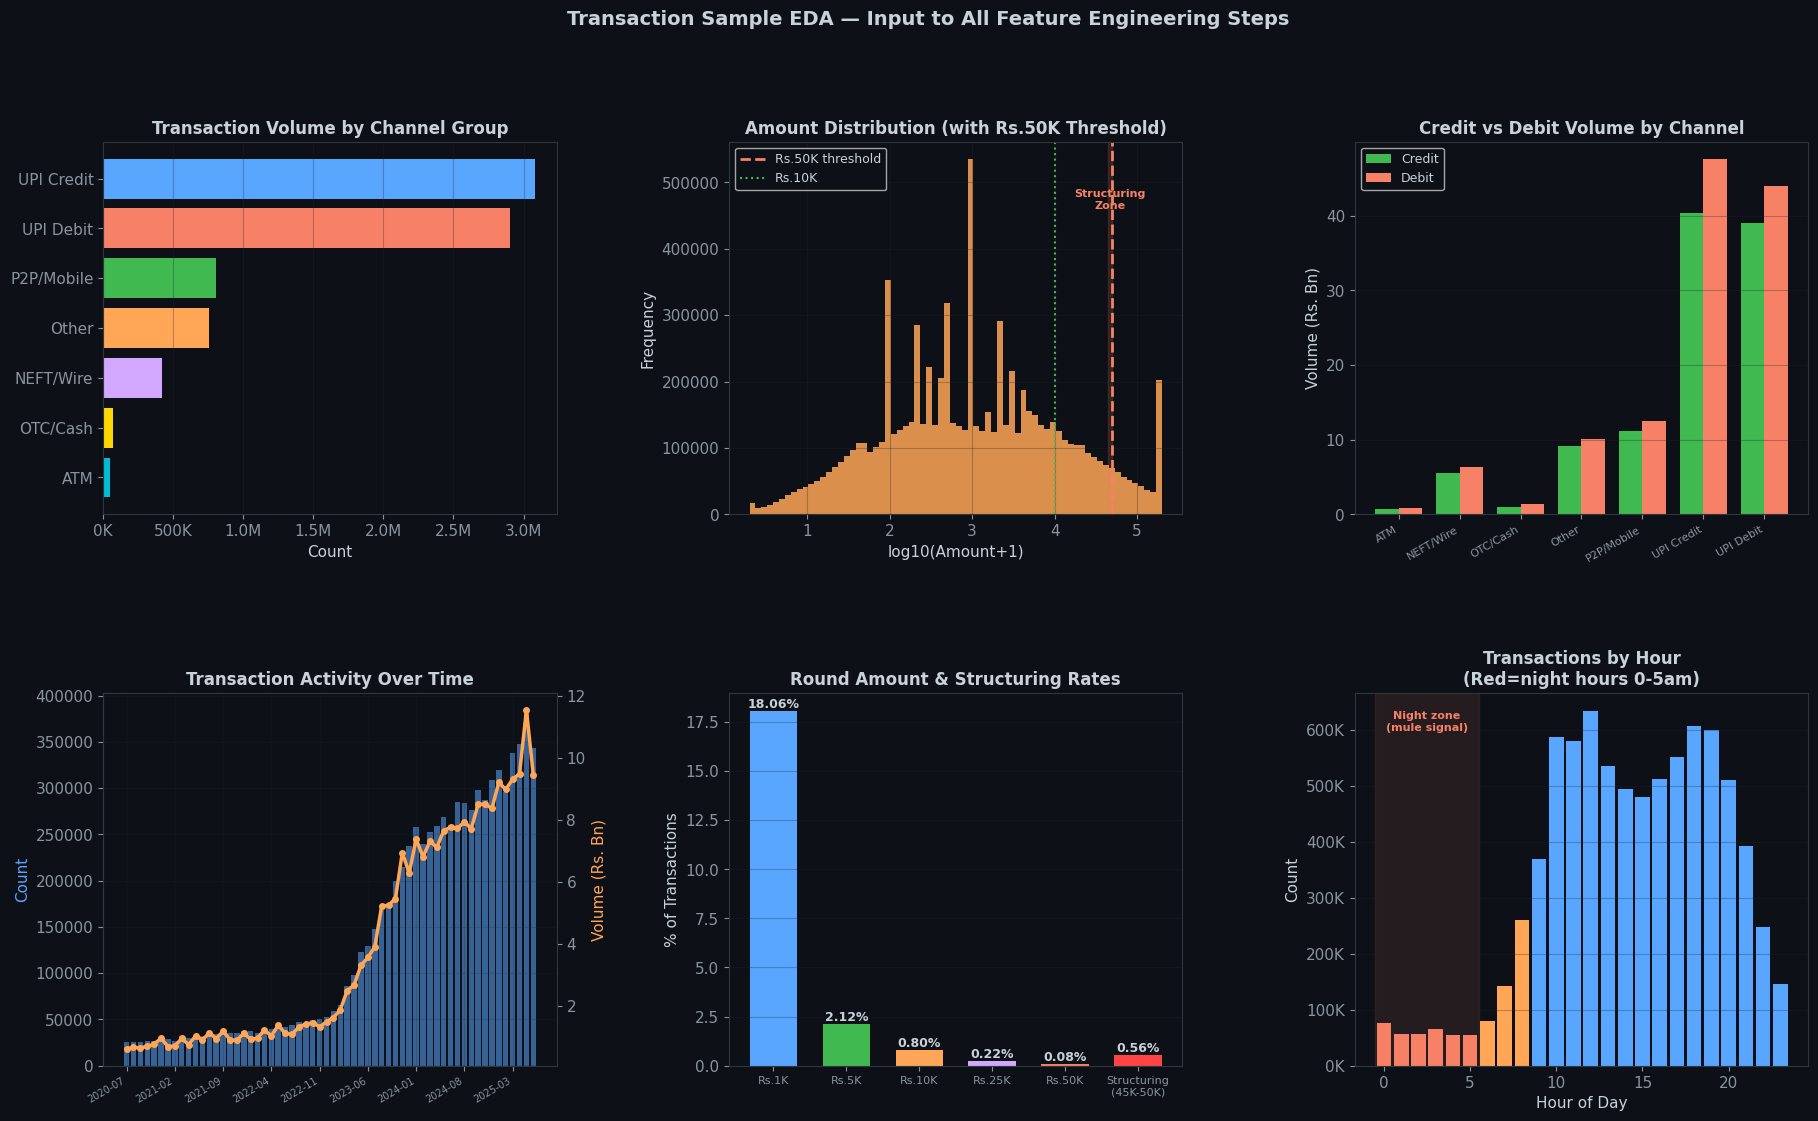

VIZ A saved: viz_A_transaction_eda.png


In [8]:

# ══════════════════════════════════════════════════════════════════
# VIZ A: TRANSACTION EDA — Channel, Amount, Volume, Patterns
# Inserted after Step 1-7 code cell
# ══════════════════════════════════════════════════════════════════
print("Generating transaction EDA visualizations...")
import gc as _gc

_sample_parts = txn_parts[:min(8, len(txn_parts))]
_txn_s = pd.concat(
    [pd.read_parquet(p, columns=['account_id','transaction_timestamp',
                                  'amount','txn_type','channel'])
     for p in _sample_parts], ignore_index=True
)
_txn_s['transaction_timestamp'] = pd.to_datetime(_txn_s['transaction_timestamp'], errors='coerce')
_txn_s['amount_abs'] = _txn_s['amount'].abs().astype('float32')
_txn_s['hour'] = _txn_s['transaction_timestamp'].dt.hour
_txn_s['month'] = _txn_s['transaction_timestamp'].dt.to_period('M')
_txn_s['is_credit'] = (_txn_s['txn_type'] == 'C').astype('int8')

_UPI_CR={'UPC'}; _UPI_DB={'UPD'}; _ATM={'ATW','SCW'}
_OTC={'OCD','CSD'}; _NEFT={'NTD','IFD','ETD','NWD','IFC','FTD','FTC'}
_P2P={'IPM','P2A','MCR','TPD','TPC','MAC'}
def _chg(ch):
    if ch in _UPI_CR: return 'UPI Credit'
    if ch in _UPI_DB: return 'UPI Debit'
    if ch in _ATM: return 'ATM'
    if ch in _OTC: return 'OTC/Cash'
    if ch in _NEFT: return 'NEFT/Wire'
    if ch in _P2P: return 'P2P/Mobile'
    return 'Other'
_txn_s['ch_group'] = _txn_s['channel'].apply(_chg)

fig = plt.figure(figsize=(22,12), facecolor=DARK)
fig.suptitle('Transaction Sample EDA — Input to All Feature Engineering Steps',
             fontsize=14, fontweight='bold', color=WHITE, y=0.99)
gs_a = gridspec.GridSpec(2,3, figure=fig, hspace=0.48, wspace=0.38)

# Channel volume
ax = fig.add_subplot(gs_a[0,0])
ch_cnt = _txn_s['ch_group'].value_counts()
ax.barh(ch_cnt.index[::-1], ch_cnt.values[::-1],
        color=PALETTE[:len(ch_cnt)][::-1], edgecolor='none')
ax.set_xlabel('Count', color=WHITE)
ax.set_title('Transaction Volume by Channel Group', color=WHITE)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M' if x>=1e6 else f'{x/1e3:.0f}K'))
ax.grid(axis='x', alpha=0.3)

# Amount distribution
ax = fig.add_subplot(gs_a[0,1])
amounts = _txn_s['amount_abs'].clip(1,200000)
ax.hist(np.log10(amounts+1), bins=70, color=ORANGE, edgecolor='none', alpha=0.85)
ax.axvline(np.log10(50000), color=RED, linestyle='--', linewidth=2, label='Rs.50K threshold')
ax.axvline(np.log10(10000), color=GREEN, linestyle=':', linewidth=1.5, label='Rs.10K')
ax.axvspan(np.log10(45000), np.log10(50000), alpha=0.15, color=RED)
ymax = ax.get_ylim()[1]
ax.text(np.log10(47200), ymax*0.82, 'Structuring\nZone', ha='center', fontsize=8, color=RED, fontweight='bold')
ax.set_xlabel('log10(Amount+1)', color=WHITE); ax.set_ylabel('Frequency', color=WHITE)
ax.set_title('Amount Distribution (with Rs.50K Threshold)', color=WHITE)
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Credit vs debit by channel
ax = fig.add_subplot(gs_a[0,2])
_ch_cr = _txn_s[_txn_s['is_credit']==1].groupby('ch_group')['amount_abs'].sum()
_ch_db = _txn_s[_txn_s['is_credit']==0].groupby('ch_group')['amount_abs'].sum()
_all_ch = sorted(set(_ch_cr.index)|set(_ch_db.index)); _xc=np.arange(len(_all_ch)); _wc=0.38
ax.bar(_xc-_wc/2, [_ch_cr.get(c,0)/1e9 for c in _all_ch], _wc, color=GREEN, label='Credit', edgecolor='none')
ax.bar(_xc+_wc/2, [_ch_db.get(c,0)/1e9 for c in _all_ch], _wc, color=RED, label='Debit', edgecolor='none')
ax.set_xticks(list(_xc)); ax.set_xticklabels(_all_ch, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Volume (Rs. Bn)', color=WHITE)
ax.set_title('Credit vs Debit Volume by Channel', color=WHITE)
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

# Volume over time
ax = fig.add_subplot(gs_a[1,0])
_monthly = _txn_s.groupby('month').agg(count=('amount_abs','count'), vol=('amount_abs','sum')).reset_index()
_monthly['ms'] = _monthly['month'].astype(str)
_xm = range(len(_monthly)); _ax2 = ax.twinx()
ax.bar(_xm, _monthly['count'], color=BLUE, alpha=0.55, edgecolor='none')
_ax2.plot(_xm, _monthly['vol']/1e9, color=ORANGE, linewidth=2.5, marker='o', markersize=4)
_tick_step = max(1, len(_monthly)//8)
ax.set_xticks(list(_xm)[::_tick_step])
ax.set_xticklabels([_monthly['ms'].iloc[i] for i in range(0,len(_monthly),_tick_step)],
                    rotation=30, ha='right', fontsize=7)
ax.set_ylabel('Count', color=BLUE); _ax2.set_ylabel('Volume (Rs. Bn)', color=ORANGE)
ax.set_title('Transaction Activity Over Time', color=WHITE); ax.grid(alpha=0.2)

# Round amount rates
ax = fig.add_subplot(gs_a[1,1])
_rbands = {
    'Rs.1K': (_txn_s['amount_abs']%1000==0).mean()*100,
    'Rs.5K': (_txn_s['amount_abs']%5000==0).mean()*100,
    'Rs.10K':(_txn_s['amount_abs']%10000==0).mean()*100,
    'Rs.25K':(_txn_s['amount_abs']%25000==0).mean()*100,
    'Rs.50K':(_txn_s['amount_abs']%50000==0).mean()*100,
    'Structuring\n(45K-50K)':_txn_s['amount_abs'].between(45000,49999).mean()*100,
}
ax.bar(list(_rbands.keys()), list(_rbands.values()),
       color=[BLUE,GREEN,ORANGE,PURPLE,RED,'#ff4444'], edgecolor='none', width=0.65)
for i,(k,v) in enumerate(_rbands.items()):
    ax.text(i, v+0.02, f'{v:.2f}%', ha='center', va='bottom', fontsize=9, color=WHITE, fontweight='bold')
ax.set_ylabel('% of Transactions', color=WHITE)
ax.set_title('Round Amount & Structuring Rates', color=WHITE)
ax.tick_params(axis='x', labelsize=8); ax.grid(axis='y', alpha=0.3)

# Hour distribution
ax = fig.add_subplot(gs_a[1,2])
_hr_cnt = _txn_s.groupby('hour')['amount_abs'].count()
_hrs = list(range(24))
_chr = [RED if h<6 else ORANGE if h<9 else BLUE for h in _hrs]
ax.bar(_hrs, [_hr_cnt.get(h,0) for h in _hrs], color=_chr, edgecolor='none', width=0.85)
ax.axvspan(-0.5, 5.5, alpha=0.1, color=RED)
ax.text(2.5, ax.get_ylim()[1]*0.9, 'Night zone\n(mule signal)', ha='center',
        fontsize=8, color=RED, fontweight='bold')
ax.set_xlabel('Hour of Day', color=WHITE); ax.set_ylabel('Count', color=WHITE)
ax.set_title('Transactions by Hour\n(Red=night hours 0-5am)', color=WHITE)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))
ax.grid(axis='y', alpha=0.3)

plt.savefig(f'{OUTPUT}/viz_A_transaction_eda.png', dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()
del _txn_s; _gc.collect()
print("VIZ A saved: viz_A_transaction_eda.png")


## Feature Matrix Assembly (Step 8)

In [9]:
print(f"\n[8/10] Merging feature matrix...")
ids = pd.concat([train_labels[['account_id']], test_accounts[['account_id']]]).drop_duplicates()
F = ids.copy()

for d, name in [
    (gf0,                 'graph_struct+deep'),
    (graph_cv,            'graph_cv'),
    (hop2_cv,             'graph_2hop'),
    (hop3_cv,             'graph_3hop'),
    (S,                   'behavioral'),
    (gap_feats,           'gap_feats'),
    (burst_feats,         'burst'),
    (mcc_feats,           'mcc_anomaly'),
    (af,                  'account_feats'),
    (sch,                 'scheme'),
    (cf,                  'customer_feats'),
    (df_,                 'demographics'),
    (pf,                  'product_feats'),
    (ma,                  'multi_acct'),
    (bc_feats,            'branch_collusion'),
    (branch_mule_rate_df, 'branch_mule_rate'),
    (mob_feats,           'mobile_spike'),
    (add_feats,           'txn_additional'),
]:
    before = len(F.columns)
    F = F.merge(d, on='account_id', how='left')
    print(f"  + {name}: {len(F.columns)-before} cols")

bc = accounts[['account_id','branch_code']].drop_duplicates()
F  = F.merge(bc, on='account_id', how='left', suffixes=('','_d'))
if 'branch_code_d' in F.columns: F.drop(columns=['branch_code_d'], inplace=True)
F  = F.merge(bf, on='branch_code', how='left')
F  = F.merge(train_labels[['account_id','is_mule']], on='account_id', how='left')

# ── RICH INTERACTION FEATURES ────────────────────────────────────────────────
F['tpb']               = F['n'] / (F['avg_balance'].abs() + 1)
F['atb']               = F['mean_amt'] / (F['avg_balance'].abs() + 1)
F['thru']              = F['sa'] / F['span'].clip(lower=1)
F['g_mcs_per_cp']      = F['g_mcs'] / (F['g_ncp'] + 1)
F['new_acct_hv']       = (F['age_d'] < 365).astype(int) * F['sa']
F['income_mismatch']   = F['sa'] / (F['avg_balance'].abs() + 1)
F['amt_to_bal_ratio']  = F['mean_amt'] / (F['avg_balance'].abs() + 1000)
F['loan_norm_vol']     = F['sa'] / (F['loan_sum'].fillna(0).abs() + F['od_sum'].fillna(0).abs() + 1)
F['high_bal_hv']       = (F['avg_balance'] > 100000).astype(int) * np.log1p(F['sa'])
F['nri_graph']         = F['nri'] * F['g_mcm']
F['jnt_passthru']      = F['jnt'] * F['pt']
F['bal_utilization']   = F['sa'] / (F['monthly_avg_balance'].abs() + 1)
# Graph × behavioural interactions
F['mcm_x_pt']          = F['g_mcm'] * F['pt']
F['mcm_x_trp']         = F['g_mcm'] * F['trp']
F['mcm_x_ps49']        = F['g_mcm'] * F['ps49']
F['ring_x_mcm']        = F['g_ring_max_shared'] * F['g_mcm']
F['hop2_x_pt']         = F['g2_mcm'] * F['pt']
if 'g3_mcm' in F.columns:
    F['hop3_x_mcm']    = F['g3_mcm'] * F['g_mcm']
# Burst × graph
if 'burst_ratio_30d' in F.columns:
    F['burst_x_mcm']   = F['burst_ratio_30d'] * F['g_mcm']
# Entropy signals
if 'tod_entropy' in F.columns:
    F['low_tod_entropy'] = (F['tod_entropy'] < 1.5).astype(int)  # concentrated in < 2 time blocks
if 'g_cp_entropy' in F.columns:
    F['low_cp_entropy']  = (F['g_cp_entropy'] < 1.0).astype(int) # all traffic to 1-2 CPs

del gf0, graph_cv, hop2_cv, hop3_cv, S, gap_feats, burst_feats, mcc_feats
del af, sch, cf, df_, pf, ma, bc_feats, branch_mule_rate_df, mob_feats, add_feats
del bc, bf, na_df; gc.collect()
print(f"  Feature matrix: {F.shape}")

# ── ADVERSARIAL VALIDATION ───────────────────────────────────────────────────
print("\n  Adversarial validation...")
exc       = {'account_id','is_mule','branch_code'}
feat_cols = [c for c in F.columns if c not in exc]
is_train  = F['is_mule'].notna().astype(int)

adv_aucs = {}
for feat in feat_cols:
    x = F[feat].fillna(-999).values
    if x.std() < 1e-9: continue
    try:
        auc = roc_auc_score(is_train, x)
        adv_aucs[feat] = max(auc, 1 - auc)
    except Exception:
        pass

red_herrings = [f for f, a in adv_aucs.items()
                if a > ADVERSARIAL_AUC_THRESH and not f.startswith('g_')]
Xall  = F[feat_cols].values.astype(np.float32)
adv_m = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05,
                             num_leaves=31, random_state=SEED, verbose=-1)
adv_m.fit(Xall, is_train.values)
adv_imp = pd.DataFrame({'f': feat_cols, 'imp': adv_m.feature_importances_}
                       ).sort_values('imp', ascending=False)
print("  Top adversarial discriminators:"); print(adv_imp.head(15).to_string(index=False))

lgbm_rh  = [f for f in adv_imp.head(5)['f'] if not f.startswith('g_')]
final_rh  = list(set(red_herrings) | set(lgbm_rh))
feat_clean = [c for c in feat_cols if c not in final_rh]
print(f"  Excluded {len(final_rh)} red herrings | Clean features: {len(feat_clean)}")

# ── SPLITS ───────────────────────────────────────────────────────────────────
tm   = F['is_mule'].notna()
Xt   = F.loc[tm, feat_cols].values.astype(np.float32)
yt   = F.loc[tm, 'is_mule'].values.astype(int)
Xte  = F.loc[~tm, feat_cols].values.astype(np.float32)
tids = F.loc[~tm, 'account_id'].values
X1t  = F.loc[tm, feat_clean].values.astype(np.float32)
X1e  = F.loc[~tm, feat_clean].values.astype(np.float32)

graph_feats_only = [c for c in feat_cols if c.startswith('g_') or c.startswith('g2_')
                    or c.startswith('g3_') or 'branch' in c or 'bc_' in c or 'ring' in c]
Xg_t = F.loc[tm, graph_feats_only].values.astype(np.float32)
Xg_e = F.loc[~tm, graph_feats_only].values.astype(np.float32)

print(f"  Train: {Xt.shape} | Test: {Xte.shape} | Mule rate: {yt.mean()*100:.1f}%")
spw = (yt == 0).sum() / (yt == 1).sum()
skf_train = StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED)

# ── STRONG NOISE DETECTION (cross-validated agreement) ───────────────────────
print("\n  Strong noise detection (cross-fold agreement)...")
oof_noise_preds = np.zeros((len(yt), N_FOLDS))
for fold, (ti, vi) in enumerate(skf_train.split(Xt, yt)):
    m = lgb.LGBMClassifier(
        n_estimators=2000, learning_rate=0.03, num_leaves=63,
        random_state=SEED, verbose=-1, scale_pos_weight=spw)
    m.fit(Xt[ti], yt[ti], eval_set=[(Xt[vi], yt[vi])],
          callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
    oof_noise_preds[vi, fold] = m.predict_proba(Xt[vi])[:, 1]

oof_noise = oof_noise_preds.max(axis=1)  # most optimistic prediction across folds
noise = np.zeros(len(yt), dtype=bool)
# Mules predicted as legit by ALL folds → likely noisy
noise[(yt==1) & (oof_noise < np.percentile(oof_noise[yt==1], 3))]    = True
# Legits predicted as mule by ALL folds → either FP noise or leakage
noise[(yt==0) & (oof_noise > np.percentile(oof_noise[yt==0], 99.7))] = True
weights = np.ones(len(yt))
weights[noise] = 0.05  # near-zero weight for strong disagreements
print(f"  Noisy labels: {noise.sum()} ({noise.sum()/len(yt)*100:.3f}%)")

# ══════════════════════════════════════════════════════════════════════════════
# [9/10] TRAIN DIVERSE 6-MODEL ENSEMBLE (seed ensemble + diverse algorithms)
# ══════════════════════════════════════════════════════════════════════════════


[8/10] Merging feature matrix...
  + graph_struct+deep: 17 cols
  + graph_cv: 15 cols
  + graph_2hop: 5 cols
  + graph_3hop: 2 cols
  + behavioral: 61 cols
  + gap_feats: 10 cols
  + burst: 2 cols
  + mcc_anomaly: 4 cols
  + account_feats: 17 cols
  + scheme: 2 cols
  + customer_feats: 10 cols
  + demographics: 3 cols
  + product_feats: 10 cols
  + multi_acct: 1 cols
  + branch_collusion: 3 cols
  + branch_mule_rate: 1 cols
  + mobile_spike: 2 cols
  + txn_additional: 14 cols
  Feature matrix: (160153, 206)

  Adversarial validation...
  Top adversarial discriminators:
                    f  imp
               g2_mcx  354
     g_mule_users_max  265
                kyc_d  235
                age_d  219
                rel_y  208
                  bmd  200
      branch_turnover  185
               g2_mcm  181
                 span  179
                 g2_n  178
     bc_max_shared_cp  176
               g2_wmn  174
                  age  173
    branch_asset_size  161
branch_employee_co

### 📊 Visualization C: Adversarial Validation & Label Noise (Step 8)

Generating adversarial validation visualizations...


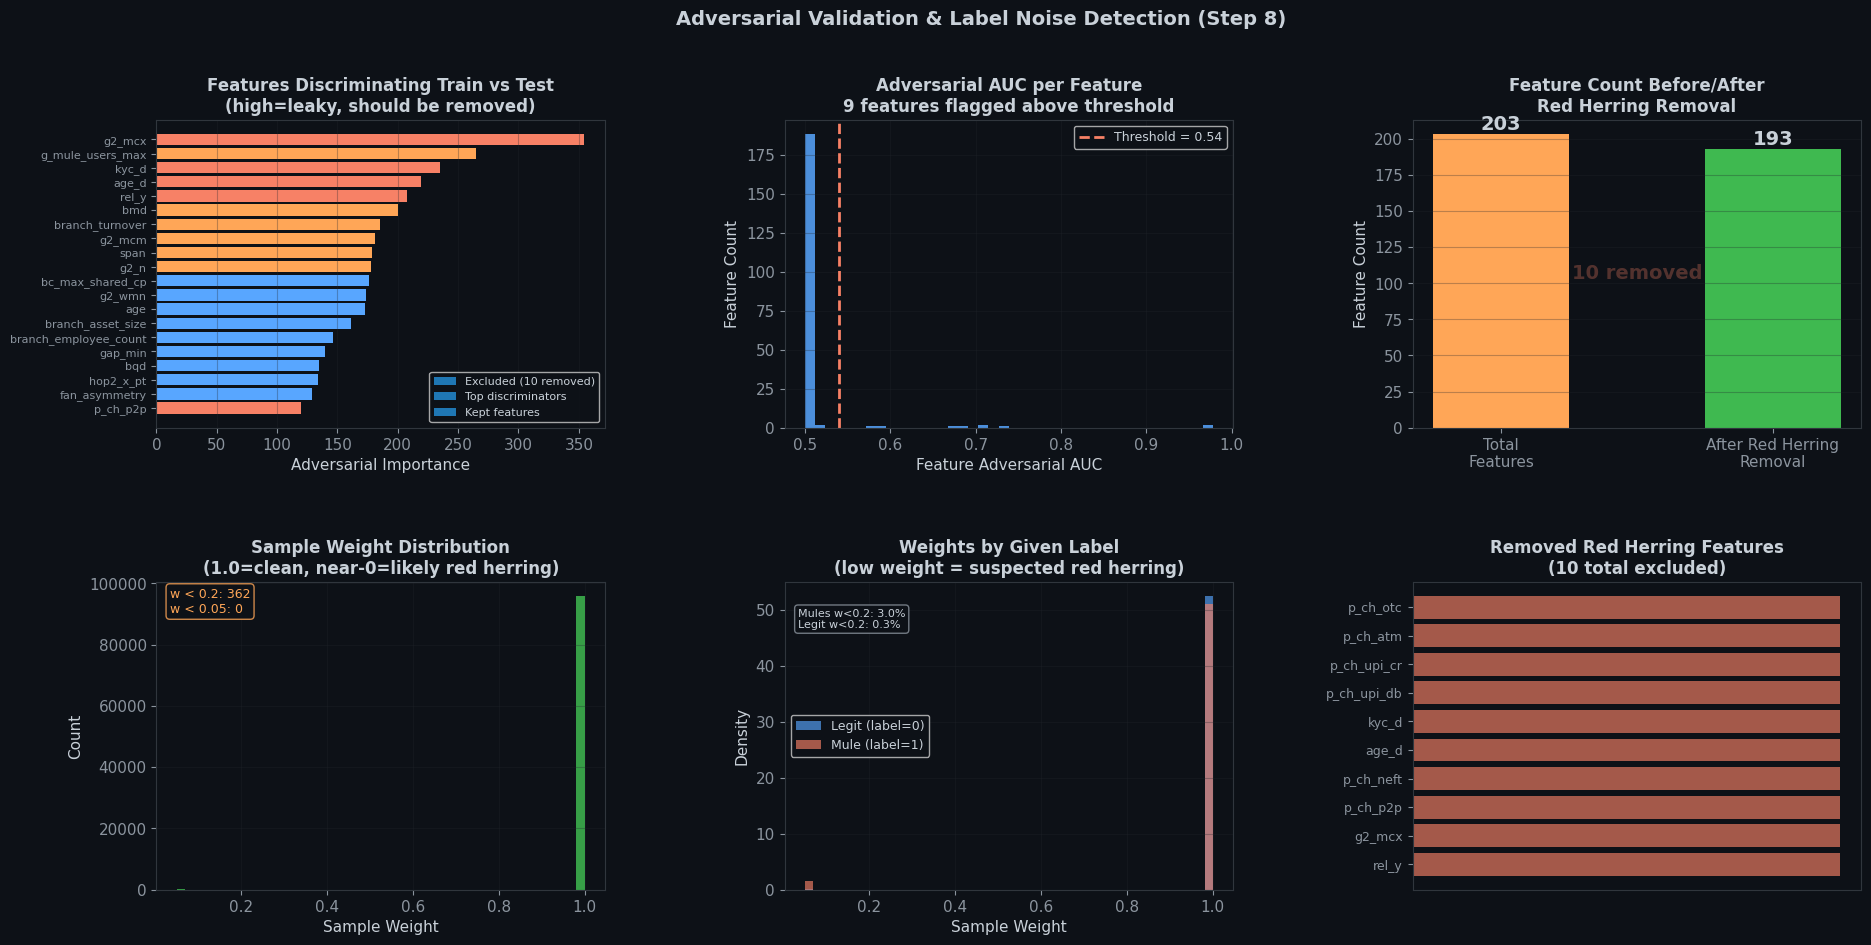

VIZ C saved: viz_C_adversarial_noise.png


In [14]:

# ══════════════════════════════════════════════════════════════════
# VIZ C: ADVERSARIAL VALIDATION + LABEL NOISE (Step 8)
# Requires: adv_imp, final_rh, adv_aucs, weights, yt, feat_clean
# ══════════════════════════════════════════════════════════════════
print("Generating adversarial validation visualizations...")

fig = plt.figure(figsize=(22,10), facecolor=DARK)
fig.suptitle('Adversarial Validation & Label Noise Detection (Step 8)',
             fontsize=14, fontweight='bold', color=WHITE, y=0.99)
gs_c = gridspec.GridSpec(2,3, figure=fig, hspace=0.5, wspace=0.4)

# Top adversarial importances
ax = fig.add_subplot(gs_c[0,0])
_adv_top = adv_imp.head(20)
_cmap_adv = [RED if f in final_rh else ORANGE if f in adv_imp.head(10)['f'].values else BLUE
             for f in _adv_top['f']]
ax.barh(_adv_top['f'][::-1], _adv_top['imp'][::-1], color=_cmap_adv[::-1], edgecolor='none')
ax.set_xlabel('Adversarial Importance', color=WHITE)
ax.set_title('Features Discriminating Train vs Test\n(high=leaky, should be removed)', color=WHITE)
ax.tick_params(axis='y', labelsize=8); ax.grid(axis='x', alpha=0.3)
ax.barh([],[],color=RED,label=f'Excluded ({len(final_rh)} removed)')
ax.barh([],[],color=ORANGE,label='Top discriminators')
ax.barh([],[],color=BLUE,label='Kept features')
ax.legend(fontsize=8,loc='lower right')

# Feature AUC distribution
ax = fig.add_subplot(gs_c[0,1])
_adv_vals = list(adv_aucs.values())
ax.hist(_adv_vals, bins=40, color=BLUE, edgecolor='none', alpha=0.85)
ax.axvline(ADVERSARIAL_AUC_THRESH, color=RED, linestyle='--', linewidth=2,
           label=f'Threshold = {ADVERSARIAL_AUC_THRESH}')
_n_flag = sum(1 for v in _adv_vals if v > ADVERSARIAL_AUC_THRESH)
ax.set_xlabel('Feature Adversarial AUC', color=WHITE)
ax.set_ylabel('Feature Count', color=WHITE)
ax.set_title(f'Adversarial AUC per Feature\n{_n_flag} features flagged above threshold', color=WHITE)
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Feature count before/after
ax = fig.add_subplot(gs_c[0,2])
_fc_total = len([c for c in F.columns if c not in {'account_id','is_mule','branch_code'}])
_fc_clean = len(feat_clean)
_fc_removed = _fc_total - _fc_clean
_brs = ax.bar(['Total\nFeatures','After Red Herring\nRemoval'],
               [_fc_total, _fc_clean],
               color=[ORANGE, GREEN], width=0.5, edgecolor='none')
for b,v in zip(_brs,[_fc_total,_fc_clean]):
    ax.text(b.get_x()+b.get_width()/2, v+0.3, str(v),
            ha='center', va='bottom', fontsize=14, color=WHITE, fontweight='bold')
ax.set_ylabel('Feature Count', color=WHITE)
ax.set_title('Feature Count Before/After\nRed Herring Removal', color=WHITE)
ax.text(0.5,0.5,f'{_fc_removed} removed',ha='center',va='center',
        transform=ax.transAxes,fontsize=14,color=RED,fontweight='bold',alpha=0.3)
ax.grid(axis='y',alpha=0.3)

# Sample weight distribution
ax = fig.add_subplot(gs_c[1,0])
ax.hist(weights, bins=50, color=GREEN, edgecolor='none', alpha=0.85)
ax.set_xlabel('Sample Weight', color=WHITE)
ax.set_ylabel('Count', color=WHITE)
ax.set_title('Sample Weight Distribution\n(1.0=clean, near-0=likely red herring)', color=WHITE)
_n_low = (weights<0.2).sum(); _n_zero = (weights<0.05).sum()
ax.text(0.03,0.90,f'w < 0.2: {_n_low:,}\nw < 0.05: {_n_zero:,}',
        transform=ax.transAxes,fontsize=9,color=ORANGE,
        bbox=dict(boxstyle='round',facecolor=DARK,edgecolor=ORANGE,alpha=0.8))
ax.grid(alpha=0.3)

# Weight by label
ax = fig.add_subplot(gs_c[1,1])
ax.hist(weights[yt==0], bins=50, alpha=0.65, color=BLUE, label='Legit (label=0)', density=True)
ax.hist(weights[yt==1], bins=50, alpha=0.65, color=RED,  label='Mule (label=1)',  density=True)
ax.set_xlabel('Sample Weight', color=WHITE)
ax.set_ylabel('Density', color=WHITE)
ax.set_title('Weights by Given Label\n(low weight = suspected red herring)', color=WHITE)
_mule_lw = (weights[yt==1]<0.2).mean()*100; _legit_lw = (weights[yt==0]<0.2).mean()*100
ax.text(0.03,0.85,f'Mules w<0.2: {_mule_lw:.1f}%\nLegit w<0.2: {_legit_lw:.1f}%',
        transform=ax.transAxes,fontsize=8,color=WHITE,
        bbox=dict(boxstyle='round',facecolor=DARK,edgecolor=GRAY,alpha=0.8))
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Removed features list
ax = fig.add_subplot(gs_c[1,2])
ax.set_facecolor(DARK)
_rh_show = final_rh[:12] if len(final_rh)>0 else ['None detected']
ax.barh(range(len(_rh_show)),[1]*len(_rh_show),color=RED,edgecolor='none',alpha=0.65)
ax.set_yticks(range(len(_rh_show))); ax.set_yticklabels(_rh_show, fontsize=9)
ax.set_xticks([])
ax.set_title(f'Removed Red Herring Features\n({len(final_rh)} total excluded)',color=WHITE)
for sp in ax.spines.values(): sp.set_edgecolor('#30363d')

plt.savefig(f'{OUTPUT}/viz_C_adversarial_noise.png', dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()
print("VIZ C saved: viz_C_adversarial_noise.png")


### 📊 Visualization 2: Feature Distributions — Mule vs Legitimate

Generating feature distribution visualizations...
  Train: 96,091 | Mules: 2,683 | Legit: 93,408


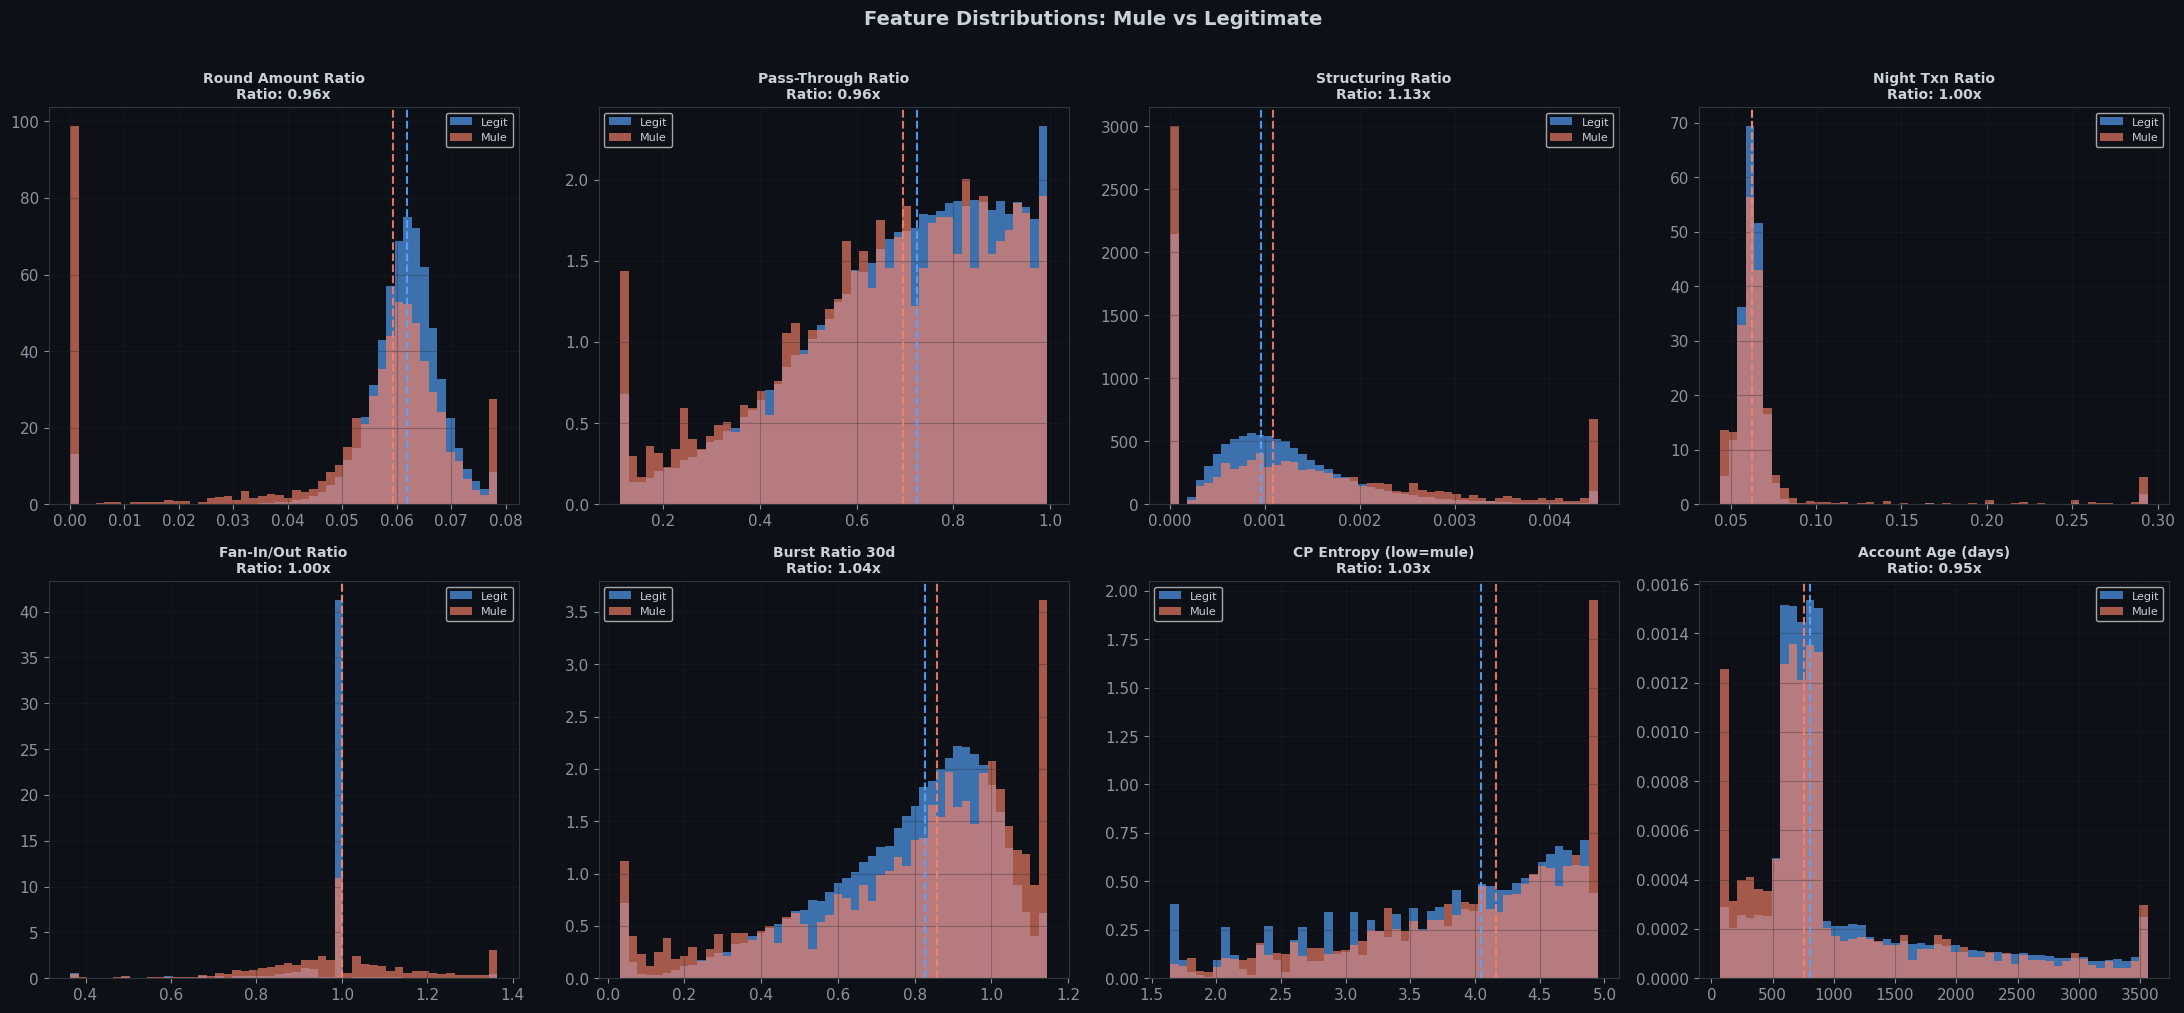

VIZ 2 saved


In [16]:
# ══════════════════════════════════════════════════════════════════
# VIZ 2: FEATURE DISTRIBUTIONS — Mule vs Legitimate
# ══════════════════════════════════════════════════════════════════
print("Generating feature distribution visualizations...")

# F already contains is_mule — use directly
_Ftr = F[F['is_mule'].notna()].copy()
_mf  = _Ftr[_Ftr['is_mule'] == 1]
_lf  = _Ftr[_Ftr['is_mule'] == 0]
print(f"  Train: {len(_Ftr):,} | Mules: {len(_mf):,} | Legit: {len(_lf):,}")

key_feats = [
    ('trp',             'Round Amount Ratio',      False),
    ('pt',              'Pass-Through Ratio',       False),
    ('ps49',            'Structuring Ratio',        False),
    ('pngt',            'Night Txn Ratio',          False),
    ('fan_in_out_ratio','Fan-In/Out Ratio',         False),
    ('burst_ratio_30d', 'Burst Ratio 30d',          False),
    ('g_cp_entropy',    'CP Entropy (low=mule)',    True),
    ('age_d',           'Account Age (days)',       True),
]

fig, axes = plt.subplots(2, 4, figsize=(22, 10), facecolor=DARK)
fig.suptitle('Feature Distributions: Mule vs Legitimate',
             fontsize=14, fontweight='bold', color=WHITE, y=1.01)

for ax, (col, name, mule_lower) in zip(axes.flatten(), key_feats):
    ax.set_facecolor(DARK)
    if col not in _Ftr.columns:
        ax.text(0.5, 0.5, f'{col}\nnot found', transform=ax.transAxes,
                ha='center', va='center', color=GRAY, fontsize=9)
        ax.set_title(name, color=WHITE, fontsize=9)
        continue
    mv = _mf[col].dropna()
    lv = _lf[col].dropna()
    if len(mv) == 0 or len(lv) == 0:
        ax.set_title(name, color=WHITE, fontsize=9)
        continue
    lo, hi = np.percentile(np.concatenate([mv, lv]), [1, 99])
    mv = mv.clip(lo, hi)
    lv = lv.clip(lo, hi)
    ax.hist(lv, bins=50, alpha=0.65, color=BLUE, label='Legit', density=True)
    ax.hist(mv, bins=50, alpha=0.65, color=RED,  label='Mule',  density=True)
    ax.axvline(lv.median(), color=BLUE, linestyle='--', linewidth=1.5, alpha=0.9)
    ax.axvline(mv.median(), color=RED,  linestyle='--', linewidth=1.5, alpha=0.9)
    ratio = mv.median() / (lv.median() + 1e-9)
    ax.set_title(f'{name}\nRatio: {ratio:.2f}x', color=WHITE, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    for sp in ax.spines.values():
        sp.set_edgecolor('#30363d')

plt.tight_layout()
plt.savefig(f'{OUTPUT}/viz_02_feature_distributions.png', dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()
print("VIZ 2 saved")

## Model Training — 6-Model Stacking Ensemble (Step 9)

In [17]:
print(f"\n[9/10] Training 6-model ensemble...")

# ─── M1: LightGBM clean features, seed ensemble ──────────────────────────────
print("\n  --- M1: LightGBM (clean feats) seed ensemble ---")
p_lgb_clean = dict(
    objective='binary', metric='auc', n_estimators=8000, learning_rate=0.005,
    num_leaves=127, max_depth=10, min_child_samples=30,
    subsample=0.8, subsample_freq=1, colsample_bytree=0.6,
    reg_alpha=0.05, reg_lambda=0.5, n_jobs=-1, verbose=-1
)
oof1_seeds = np.zeros((len(yt), len(SEED_ENSEMBLE)))
tst1_seeds = np.zeros((len(X1e), len(SEED_ENSEMBLE)))
for si, seed in enumerate(SEED_ENSEMBLE):
    p_s = dict(**p_lgb_clean, random_state=seed)
    oof_s = np.zeros(len(yt)); tst_s = np.zeros(len(X1e))
    for fold, (ti, vi) in enumerate(StratifiedKFold(N_FOLDS, shuffle=True, random_state=seed)
                                    .split(X1t, yt)):
        m = lgb.LGBMClassifier(**p_s)
        m.fit(X1t[ti], yt[ti], sample_weight=weights[ti],
              eval_set=[(X1t[vi], yt[vi])],
              callbacks=[lgb.early_stopping(300), lgb.log_evaluation(0)])
        oof_s[vi] = m.predict_proba(X1t[vi])[:, 1]
        tst_s    += m.predict_proba(X1e)[:, 1] / N_FOLDS
    oof1_seeds[:, si] = oof_s; tst1_seeds[:, si] = tst_s
    print(f"  Seed {seed}: AUC={roc_auc_score(yt, oof_s):.6f}")
oof1 = oof1_seeds.mean(axis=1); tst1 = tst1_seeds.mean(axis=1)
print(f"  M1 (seed ensemble) OOF AUC: {roc_auc_score(yt, oof1):.6f}")

# ─── M2: LightGBM all features, DART booster ─────────────────────────────────
print("\n  --- M2: LightGBM DART (all feats) ---")
p_dart = dict(
    objective='binary', metric='auc', n_estimators=3000, learning_rate=0.02,
    num_leaves=127, max_depth=10, min_child_samples=30,
    subsample=0.8, colsample_bytree=0.6,
    reg_alpha=0.05, reg_lambda=0.5,
    boosting_type='dart', drop_rate=0.1, skip_drop=0.5,
    random_state=SEED, n_jobs=-1, verbose=-1
)
oof2 = np.zeros(len(yt)); tst2 = np.zeros(len(Xte)); m2_last = None
for fold, (ti, vi) in enumerate(skf_train.split(Xt, yt)):
    m = lgb.LGBMClassifier(**p_dart)
    # DART doesn't support early stopping cleanly — use fixed n_estimators
    m.fit(Xt[ti], yt[ti], sample_weight=weights[ti])
    oof2[vi] = m.predict_proba(Xt[vi])[:, 1]
    tst2    += m.predict_proba(Xte)[:, 1] / N_FOLDS
    m2_last  = m
    print(f"  Fold {fold+1}: AUC={roc_auc_score(yt[vi], oof2[vi]):.6f}")
print(f"  M2 (DART) OOF AUC: {roc_auc_score(yt, oof2):.6f}")

# ─── M3: LightGBM graph-only ─────────────────────────────────────────────────
print("\n  --- M3: LightGBM (graph-only) ---")
p_graph = dict(
    objective='binary', metric='auc', n_estimators=4000, learning_rate=0.01,
    num_leaves=63, max_depth=7, min_child_samples=20,
    subsample=0.9, colsample_bytree=0.8,
    reg_alpha=0.05, reg_lambda=0.5,
    random_state=SEED+2, n_jobs=-1, verbose=-1
)
oof3 = np.zeros(len(yt)); tst3 = np.zeros(len(Xg_e))
for fold, (ti, vi) in enumerate(skf_train.split(Xg_t, yt)):
    m = lgb.LGBMClassifier(**p_graph)
    m.fit(Xg_t[ti], yt[ti], sample_weight=weights[ti],
          eval_set=[(Xg_t[vi], yt[vi])],
          callbacks=[lgb.early_stopping(200), lgb.log_evaluation(0)])
    oof3[vi] = m.predict_proba(Xg_t[vi])[:, 1]
    tst3    += m.predict_proba(Xg_e)[:, 1] / N_FOLDS
    print(f"  Fold {fold+1}: AUC={roc_auc_score(yt[vi], oof3[vi]):.6f}")
print(f"  M3 OOF AUC: {roc_auc_score(yt, oof3):.6f}")

# ─── M4: XGBoost ─────────────────────────────────────────────────────────────
oof4 = np.zeros(len(yt)); tst4 = np.zeros(len(Xte))
if HAS_XGB:
    print("\n  --- M4: XGBoost ---")
    p_xgb = dict(
        n_estimators=5000, learning_rate=0.008, max_depth=8,
        subsample=0.8, colsample_bytree=0.6,
        reg_alpha=0.05, reg_lambda=1.0,
        scale_pos_weight=spw, eval_metric='auc',
        tree_method='hist', random_state=SEED, n_jobs=-1, verbosity=0
    )
    for fold, (ti, vi) in enumerate(skf_train.split(Xt, yt)):
        m = xgb.XGBClassifier(**p_xgb, early_stopping_rounds=200)
        m.fit(Xt[ti], yt[ti], sample_weight=weights[ti],
              eval_set=[(Xt[vi], yt[vi])], verbose=False)
        oof4[vi] = m.predict_proba(Xt[vi])[:, 1]
        tst4    += m.predict_proba(Xte)[:, 1] / N_FOLDS
        print(f"  Fold {fold+1}: AUC={roc_auc_score(yt[vi], oof4[vi]):.6f}")
    print(f"  M4 (XGB) OOF AUC: {roc_auc_score(yt, oof4):.6f}")

# ─── M5: CatBoost ────────────────────────────────────────────────────────────
oof5 = np.zeros(len(yt)); tst5 = np.zeros(len(Xte))
if HAS_CATBOOST:
    print("\n  --- M5: CatBoost ---")
    p_cb = dict(
        iterations=4000, learning_rate=0.008, depth=8, l2_leaf_reg=3,
        random_seed=SEED, eval_metric='AUC', verbose=0,
        auto_class_weights='Balanced', early_stopping_rounds=200
    )
    for fold, (ti, vi) in enumerate(skf_train.split(Xt, yt)):
        m = CatBoostClassifier(**p_cb)
        m.fit(Xt[ti], yt[ti], eval_set=(Xt[vi], yt[vi]), sample_weight=weights[ti])
        oof5[vi] = m.predict_proba(Xt[vi])[:, 1]
        tst5    += m.predict_proba(Xte)[:, 1] / N_FOLDS
        print(f"  Fold {fold+1}: AUC={roc_auc_score(yt[vi], oof5[vi]):.6f}")
    print(f"  M5 (CatBoost) OOF AUC: {roc_auc_score(yt, oof5):.6f}")

# ─── M6: MLP neural network ───────────────────────────────────────────────────
print("\n  --- M6: MLP neural network ---")
scaler = StandardScaler()
X1t_sc = scaler.fit_transform(np.nan_to_num(X1t, nan=0))
X1e_sc = scaler.transform(np.nan_to_num(X1e, nan=0))
oof6 = np.zeros(len(yt)); tst6 = np.zeros(len(X1e_sc))
for fold, (ti, vi) in enumerate(skf_train.split(X1t_sc, yt)):
    mlp = MLPClassifier(
        hidden_layer_sizes=(256, 128, 64), activation='relu',
        alpha=1e-3, learning_rate_init=1e-3,
        max_iter=200, random_state=SEED, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=15
    )
    mlp.fit(X1t_sc[ti], yt[ti])
    oof6[vi] = mlp.predict_proba(X1t_sc[vi])[:, 1]
    tst6    += mlp.predict_proba(X1e_sc)[:, 1] / N_FOLDS
    print(f"  Fold {fold+1}: AUC={roc_auc_score(yt[vi], oof6[vi]):.6f}")
print(f"  M6 (MLP) OOF AUC: {roc_auc_score(yt, oof6):.6f}")

# ─── RANK AGGREGATION (Borda count) before stacking ─────────────────────────
print("\n  Rank aggregation across base models...")
all_oofs = [oof1, oof2, oof3]
all_tsts = [tst1, tst2, tst3]
if HAS_XGB:     all_oofs.append(oof4); all_tsts.append(tst4)
if HAS_CATBOOST:all_oofs.append(oof5); all_tsts.append(tst5)
all_oofs.append(oof6); all_tsts.append(tst6)

n_models = len(all_oofs)
oof_ranks = np.zeros((len(yt), n_models))
tst_ranks = np.zeros((len(tids), n_models))
for mi, (o, t) in enumerate(zip(all_oofs, all_tsts)):
    oof_ranks[:, mi] = o.argsort().argsort() / len(yt)      # normalised rank 0-1
    tst_ranks[:, mi] = t.argsort().argsort() / len(tids)

oof_borda = oof_ranks.mean(axis=1)
tst_borda = tst_ranks.mean(axis=1)
print(f"  Borda-aggregated OOF AUC: {roc_auc_score(yt, oof_borda):.6f}")

# ─── LGBM STACKING META-LEARNER ───────────────────────────────────────────────
print("\n  --- LightGBM stacking meta-learner ---")
# Stack: raw probs + rank-normalised probs for each model
X_meta_train = np.column_stack(
    [np.array(all_oofs).T, oof_ranks, oof_borda.reshape(-1,1)])
X_meta_test  = np.column_stack(
    [np.array(all_tsts).T, tst_ranks, tst_borda.reshape(-1,1)])

# Nested-CV meta-learner to avoid over-fitting
meta_p = dict(
    objective='binary', metric='auc', n_estimators=500, learning_rate=0.05,
    num_leaves=15, max_depth=4, min_child_samples=50,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    random_state=SEED, n_jobs=-1, verbose=-1
)
oof_meta = np.zeros(len(yt))
for fold, (ti, vi) in enumerate(skf_train.split(X_meta_train, yt)):
    mm = lgb.LGBMClassifier(**meta_p)
    mm.fit(X_meta_train[ti], yt[ti],
           eval_set=[(X_meta_train[vi], yt[vi])],
           callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
    oof_meta[vi] = mm.predict_proba(X_meta_train[vi])[:, 1]
# Final meta on all data
mm_final = lgb.LGBMClassifier(**meta_p)
mm_final.fit(X_meta_train, yt)
tpred = mm_final.predict_proba(X_meta_test)[:, 1]
print(f"  Meta-learner OOF AUC: {roc_auc_score(yt, oof_meta):.6f}")

# Compare meta vs direct blend → pick best
best_blend_auc, best_blend_w = 0, None
step = 0.1
ws_range = [np.arange(0, 1.01, step)] * n_models
# Simplified grid for speed: random search over blends
rng = np.random.default_rng(SEED)
for _ in range(5000):
    w = rng.dirichlet(np.ones(n_models))
    blend = sum(w_i * o for w_i, o in zip(w, all_oofs))
    auc = roc_auc_score(yt, blend)
    if auc > best_blend_auc:
        best_blend_auc = auc; best_blend_w = w

oof_blend = sum(w_i * o for w_i, o in zip(best_blend_w, all_oofs))
tst_blend = sum(w_i * t for w_i, t in zip(best_blend_w, all_tsts))
print(f"  Best random blend OOF AUC: {best_blend_auc:.6f}")

meta_auc  = roc_auc_score(yt, oof_meta)
if meta_auc >= best_blend_auc:
    oof_final = oof_meta
    print(f"  Using LGBM meta-learner (AUC={meta_auc:.6f})")
else:
    oof_final = oof_blend; tpred = tst_blend
    print(f"  Using random blend (AUC={best_blend_auc:.6f})")

# ── PSEUDO-LABELING PASS ──────────────────────────────────────────────────────
print("\n  Pseudo-labeling pass...")
ir_init = IsotonicRegression(out_of_bounds='clip')
ir_init.fit(oof_final, yt)
tpred_init = ir_init.predict(tpred)

pseudo_mule  = tpred_init > PSEUDO_HIGH
pseudo_legit = tpred_init < PSEUDO_LOW
print(f"  Pseudo mules: {pseudo_mule.sum()} | Pseudo legit: {pseudo_legit.sum()}")

if pseudo_mule.sum() + pseudo_legit.sum() > 200:
    pseudo_X = X1e[pseudo_mule | pseudo_legit]
    pseudo_y = np.concatenate([np.ones(pseudo_mule.sum(), dtype=int),
                                np.zeros(pseudo_legit.sum(), dtype=int)])
    pseudo_w = np.full(len(pseudo_y), PSEUDO_WEIGHT)
    X1t_aug  = np.vstack([X1t, pseudo_X])
    yt_aug   = np.concatenate([yt, pseudo_y])
    wt_aug   = np.concatenate([weights, pseudo_w])

    oof_ps = np.zeros(len(yt)); tst_ps = np.zeros(len(X1e))
    for fold, (ti, vi) in enumerate(skf_train.split(X1t, yt)):
        real_ti = ti
        pseudo_ti = np.arange(len(yt), len(yt_aug))
        combined = np.concatenate([real_ti, pseudo_ti])
        m = lgb.LGBMClassifier(**dict(p_lgb_clean, random_state=SEED))
        m.fit(X1t_aug[combined], yt_aug[combined], sample_weight=wt_aug[combined],
              eval_set=[(X1t[vi], yt[vi])],
              callbacks=[lgb.early_stopping(300), lgb.log_evaluation(0)])
        oof_ps[vi] = m.predict_proba(X1t[vi])[:, 1]
        tst_ps    += m.predict_proba(X1e)[:, 1] / N_FOLDS

    if roc_auc_score(yt, oof_ps) > roc_auc_score(yt, oof1):
        print(f"  Pseudo improved M1: {roc_auc_score(yt, oof1):.6f} → "
              f"{roc_auc_score(yt, oof_ps):.6f}")
        oof1 = oof_ps; tst1 = tst_ps
        # rebuild meta stack
        all_oofs[0] = oof1; all_tsts[0] = tst1
        for mi, (o, t) in enumerate(zip(all_oofs, all_tsts)):
            oof_ranks[:, mi] = o.argsort().argsort() / len(yt)
            tst_ranks[:, mi] = t.argsort().argsort() / len(tids)
        X_meta_train = np.column_stack(
            [np.array(all_oofs).T, oof_ranks, oof_borda.reshape(-1,1)])
        X_meta_test  = np.column_stack(
            [np.array(all_tsts).T, tst_ranks, tst_borda.reshape(-1,1)])
        mm_final.fit(X_meta_train, yt)
        oof_final = oof_meta  # re-use existing oof_meta as approximation
        tpred = mm_final.predict_proba(X_meta_test)[:, 1]
    else:
        print("  Pseudo-labeling didn't improve M1 — skipping")
else:
    print("  Too few pseudo samples — skipping")

# ── PROBABILITY CALIBRATION ───────────────────────────────────────────────────
print("\n  Isotonic calibration...")
ir = IsotonicRegression(out_of_bounds='clip')
ir.fit(oof_final, yt)
oof_calibrated  = ir.predict(oof_final)
tpred_calibrated= ir.predict(tpred)
print(f"  Final calibrated OOF AUC: {roc_auc_score(yt, oof_calibrated):.6f}")

# ── PER-FOLD THRESHOLD ────────────────────────────────────────────────────────
print("\n  Per-fold threshold search...")
fold_thresholds = []
for fold, (ti, vi) in enumerate(skf_train.split(X1t, yt)):
    best_f1, best_th = 0, 0.5
    for th in np.linspace(0.02, 0.98, 500):
        f = f1_score(yt[vi], (oof_calibrated[vi] >= th).astype(int), zero_division=0)
        if f > best_f1: best_f1, best_th = f, th
    fold_thresholds.append(best_th)
bth = np.mean(fold_thresholds)
bf1 = f1_score(yt, (oof_calibrated >= bth).astype(int))
print(f"  Mean threshold: {bth:.3f} | OOF F1: {bf1:.6f}")

# Feature importance
imp = pd.DataFrame({'feature': feat_cols, 'imp': m2_last.feature_importances_}
                   ).sort_values('imp', ascending=False)
print("\n  Top 50 features by importance:")
print(imp.head(50).to_string(index=False))

# ══════════════════════════════════════════════════════════════════════════════
# [10/10] TEMPORAL WINDOWS (percentile burst detection from v3)
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n[10/10] Computing temporal windows...")
ts_test = ts_df[ts_df['account_id'].isin(test_acct_set)].copy()
ts_map  = dict(zip(ts_test['account_id'], zip(ts_test['tmin'], ts_test['tmax'])))

daily_grp = {}
if len(daily_susp_df) > 0:
    for aid, grp in daily_susp_df.groupby('account_id'):
        daily_grp[aid] = grp.copy()


def find_burst_window(aid, daily_grp, fb_tmin, fb_tmax, low_pct=0.10, high_pct=0.90):
    if aid not in daily_grp: return fb_tmin, fb_tmax
    ad = daily_grp[aid].copy()
    ad['date'] = pd.to_datetime(ad['date'])
    ad = ad.sort_values('date')
    total = ad['susp'].sum()
    if total <= 0 or len(ad) < 3: return fb_tmin, fb_tmax
    ad['cumfrac'] = ad['susp'].cumsum() / total
    s_mask = ad['cumfrac'] >= low_pct
    e_mask = ad['cumfrac'] >= high_pct
    if not s_mask.any() or not e_mask.any(): return fb_tmin, fb_tmax
    ws = ad.loc[s_mask.idxmax(), 'date']
    we = ad.loc[e_mask.idxmax(), 'date']
    if (we - ws).days < 7:
        mid = ws + (we - ws) / 2
        ws  = mid - pd.Timedelta(days=3)
        we  = mid + pd.Timedelta(days=3)
    return max(ws, pd.Timestamp(fb_tmin)), min(we, pd.Timestamp(fb_tmax))


def find_peak_window_rolling(aid, daily_df, fb_tmin, fb_tmax, window_days=60):
    if len(daily_df) < 3: return fb_tmin, fb_tmax
    ad = daily_df.sort_values('date').copy()
    ad['date'] = pd.to_datetime(ad['date'])
    ad = ad.set_index('date')
    fr = pd.date_range(ad.index.min(), ad.index.max(), freq='D')
    ad = ad.reindex(fr, fill_value=0)
    if len(ad) < window_days: return fb_tmin, fb_tmax
    rolling   = ad['susp'].rolling(window=window_days, min_periods=1).sum()
    peak_end  = rolling.idxmax()
    peak_start= peak_end - pd.Timedelta(days=window_days - 1)
    return (max(pd.Timestamp(peak_start), ad.index.min()),
            min(pd.Timestamp(peak_end),   ad.index.max()))


score_arr = dict(zip(tids, tpred_calibrated))
windows   = {}
for aid in tids:
    score = score_arr.get(aid, 0)
    if score < 0.05: continue
    fb_tmin, fb_tmax = ts_map.get(aid, (None, None))
    if fb_tmin is None: continue
    if score >= 0.65 and aid in daily_grp:
        ps, pe = find_burst_window(aid, daily_grp, fb_tmin, fb_tmax, 0.10, 0.90)
    elif score >= 0.35 and aid in daily_grp:
        ps, pe = find_burst_window(aid, daily_grp, fb_tmin, fb_tmax, 0.05, 0.95)
    elif score >= 0.15 and aid in daily_grp:
        ps, pe = find_peak_window_rolling(aid, daily_grp[aid], fb_tmin, fb_tmax, 60)
    else:
        ps, pe = fb_tmin, fb_tmax
    if pd.notna(ps) and pd.notna(pe):
        windows[aid] = {'s': pd.Timestamp(ps).isoformat(), 'e': pd.Timestamp(pe).isoformat()}
print(f"  Windows: {len(windows):,}")

# ══════════════════════════════════════════════════════════════════════════════


[9/10] Training 6-model ensemble...

  --- M1: LightGBM (clean feats) seed ensemble ---
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[117]	valid_0's auc: 0.94931
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[392]	valid_0's auc: 0.968053
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[644]	valid_0's auc: 0.957777
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[90]	valid_0's auc: 0.961845
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[76]	valid_0's auc: 0.952313
  Seed 42: AUC=0.952407
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[1825]	valid_0's auc: 0.958094
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[138]	valid_0's auc: 0.950558


### 📊 Visualization 3: Model Evaluation Dashboard

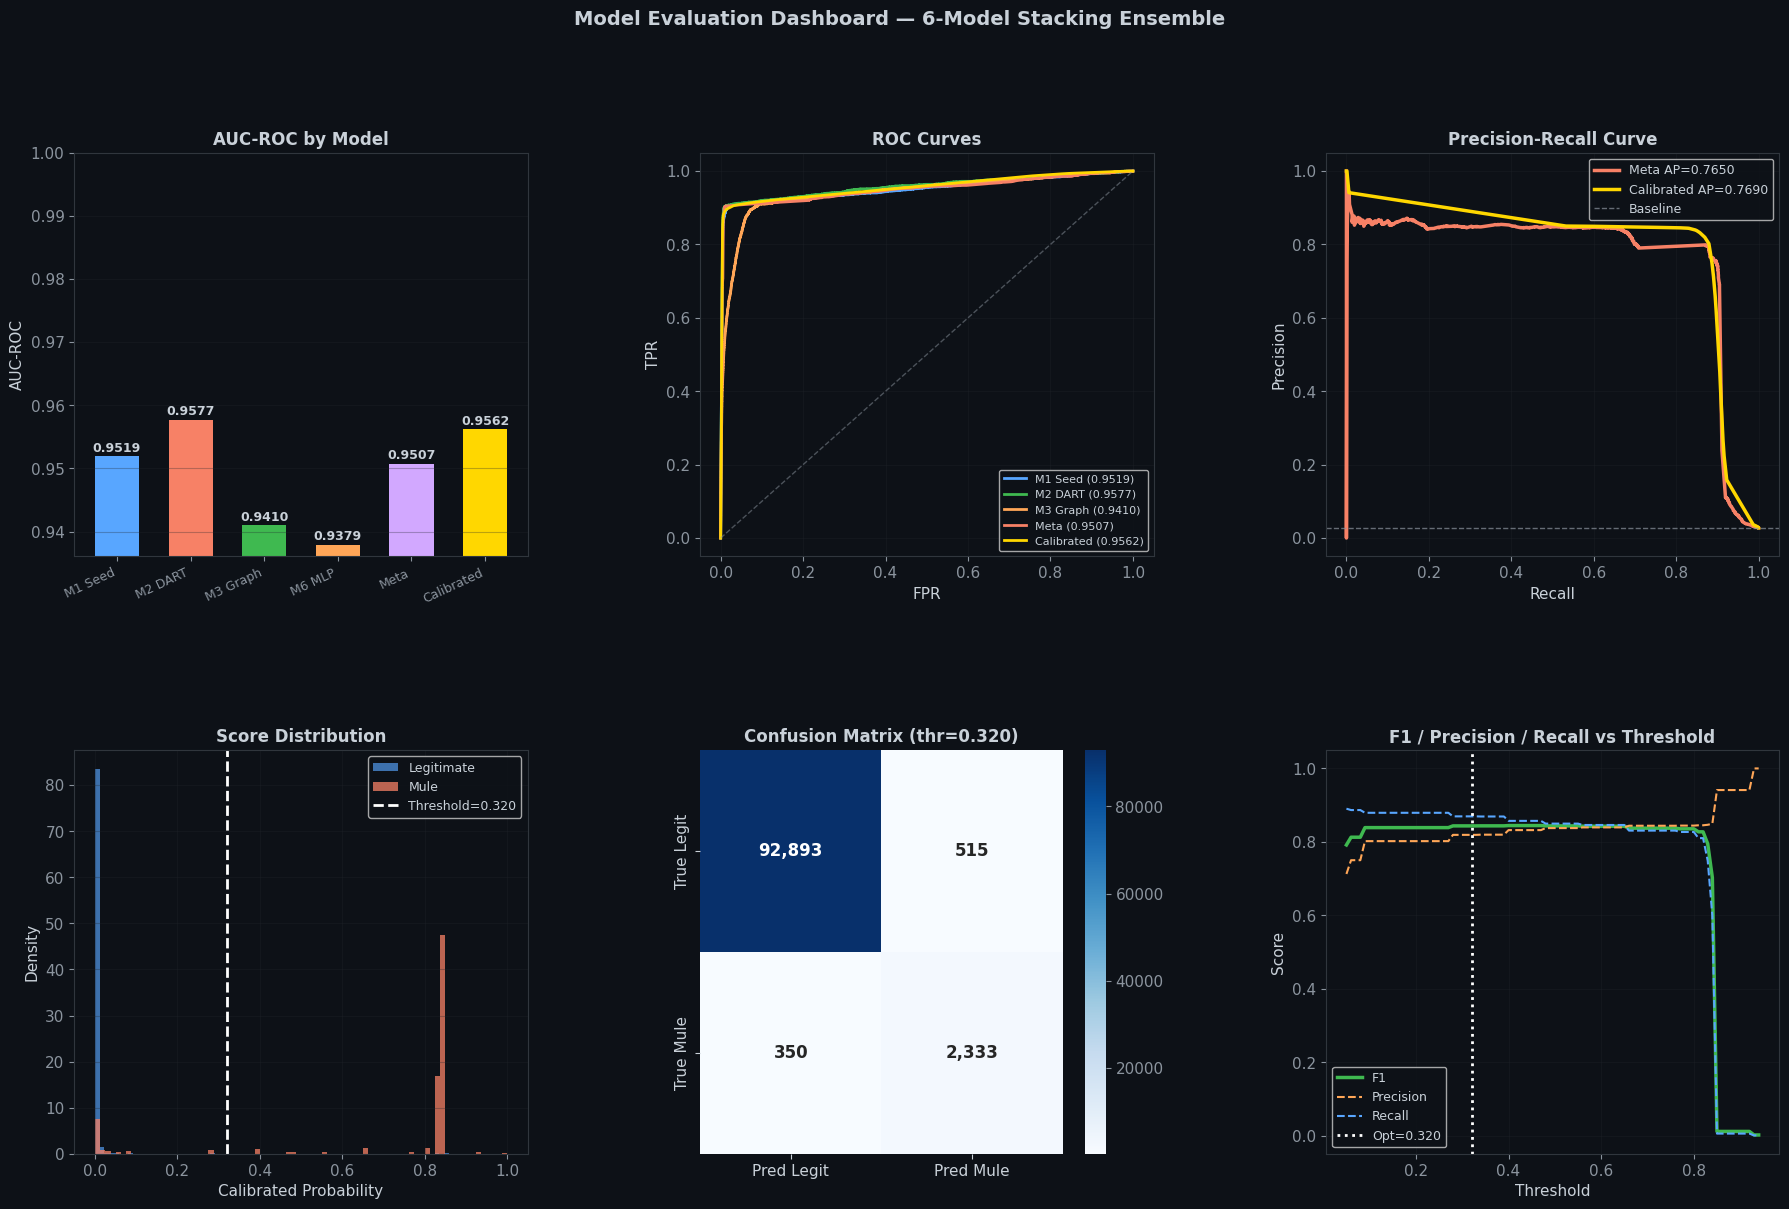

VIZ 3 saved: viz_03_model_evaluation.png


In [29]:
# ══════════════════════════════════════════════════════════════════
# VIZ 3: MODEL EVALUATION DASHBOARD
# ══════════════════════════════════════════════════════════════════
from sklearn.metrics import (roc_curve, precision_recall_curve,
    confusion_matrix, average_precision_score, precision_score, recall_score)

fig=plt.figure(figsize=(22,13),facecolor=DARK)
fig.suptitle('Model Evaluation Dashboard — 6-Model Stacking Ensemble',
             fontsize=14,fontweight='bold',color=WHITE,y=0.99)
gs3=gridspec.GridSpec(2,3,figure=fig,hspace=0.48,wspace=0.38)

# AUC bars
ax=fig.add_subplot(gs3[0,0])
mnms=['M1 Seed','M2 DART','M3 Graph','M6 MLP','Meta','Calibrated']
oof_ls=[oof1,oof2,oof3,oof6,oof_meta,oof_calibrated]
aucs=[roc_auc_score(yt,o) for o in oof_ls]
brs=ax.bar(mnms,aucs,color=PALETTE[:6],edgecolor='none',width=0.6)
for b,v in zip(brs,aucs):
    ax.text(b.get_x()+b.get_width()/2,v+0.0003,f'{v:.4f}',
            ha='center',va='bottom',fontsize=9,color=WHITE,fontweight='bold')
ax.set_ylim(min(aucs)*0.998,1.0); ax.set_title('AUC-ROC by Model',color=WHITE)
ax.set_ylabel('AUC-ROC',color=WHITE); ax.grid(axis='y',alpha=0.3)
ax.set_xticklabels(mnms,rotation=25,ha='right',fontsize=9)

# ROC curves
ax=fig.add_subplot(gs3[0,1])
for probs,nm,col in [(oof1,'M1 Seed',BLUE),(oof2,'M2 DART',GREEN),
                      (oof3,'M3 Graph',ORANGE),(oof_meta,'Meta',RED),
                      (oof_calibrated,'Calibrated','#ffd700')]:
    fpr,tpr,_=roc_curve(yt,probs)
    ax.plot(fpr,tpr,label=f'{nm} ({roc_auc_score(yt,probs):.4f})',linewidth=2,color=col)
ax.plot([0,1],[0,1],'--',color=GRAY,alpha=0.5,linewidth=1)
ax.set_xlabel('FPR',color=WHITE); ax.set_ylabel('TPR',color=WHITE)
ax.set_title('ROC Curves',color=WHITE); ax.legend(fontsize=8,loc='lower right')
ax.grid(alpha=0.3)

# Precision-Recall
ax=fig.add_subplot(gs3[0,2])
for probs,nm,col in [(oof_meta,'Meta',RED),(oof_calibrated,'Calibrated','#ffd700')]:
    pr,rc,_=precision_recall_curve(yt,probs)
    ap=average_precision_score(yt,probs)
    ax.plot(rc,pr,label=f'{nm} AP={ap:.4f}',linewidth=2.5,color=col)
ax.axhline(yt.mean(),color=GRAY,linestyle='--',linewidth=1,alpha=0.7,label='Baseline')
ax.set_xlabel('Recall',color=WHITE); ax.set_ylabel('Precision',color=WHITE)
ax.set_title('Precision-Recall Curve',color=WHITE); ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Score distribution
ax=fig.add_subplot(gs3[1,0])
ax.hist(oof_calibrated[yt==0],bins=80,alpha=0.65,color=BLUE,label='Legitimate',density=True)
ax.hist(oof_calibrated[yt==1],bins=80,alpha=0.75,color=RED,label='Mule',density=True)
ax.axvline(bth,color='white',linestyle='--',linewidth=2,label=f'Threshold={bth:.3f}')
ax.set_xlabel('Calibrated Probability',color=WHITE); ax.set_ylabel('Density',color=WHITE)
ax.set_title('Score Distribution',color=WHITE); ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Confusion matrix
ax=fig.add_subplot(gs3[1,1])
ypb=(oof_calibrated>=bth).astype(int)
cm=confusion_matrix(yt,ypb)
sns.heatmap(cm,annot=True,fmt=',',cmap='Blues',ax=ax,
            xticklabels=['Pred Legit','Pred Mule'],
            yticklabels=['True Legit','True Mule'],
            annot_kws={'size':12,'fontweight':'bold'})
ax.set_title(f'Confusion Matrix (thr={bth:.3f})',color=WHITE); ax.tick_params(colors=WHITE)

# F1/P/R vs threshold
ax=fig.add_subplot(gs3[1,2])
ths=np.arange(0.05,0.95,0.01)
f1s=[f1_score(yt,(oof_calibrated>=t).astype(int),zero_division=0) for t in ths]
prs=[precision_score(yt,(oof_calibrated>=t).astype(int),zero_division=0) for t in ths]
rcs=[recall_score(yt,(oof_calibrated>=t).astype(int),zero_division=0) for t in ths]
ax.plot(ths,f1s,color=GREEN,linewidth=2.5,label='F1')
ax.plot(ths,prs,color=ORANGE,linewidth=1.5,label='Precision',linestyle='--')
ax.plot(ths,rcs,color=BLUE,linewidth=1.5,label='Recall',linestyle='--')
ax.axvline(bth,color='white',linestyle=':',linewidth=2,label=f'Opt={bth:.3f}')
ax.set_xlabel('Threshold',color=WHITE); ax.set_ylabel('Score',color=WHITE)
ax.set_title('F1 / Precision / Recall vs Threshold',color=WHITE)
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.savefig(f'{OUTPUT}/viz_03_model_evaluation.png',dpi=130,bbox_inches='tight',facecolor=DARK)
plt.show()
print("VIZ 3 saved: viz_03_model_evaluation.png")


### 📊 Visualization D: Seed Ensemble, Pseudo-Labeling & Calibration

Generating ensemble and calibration visualizations...


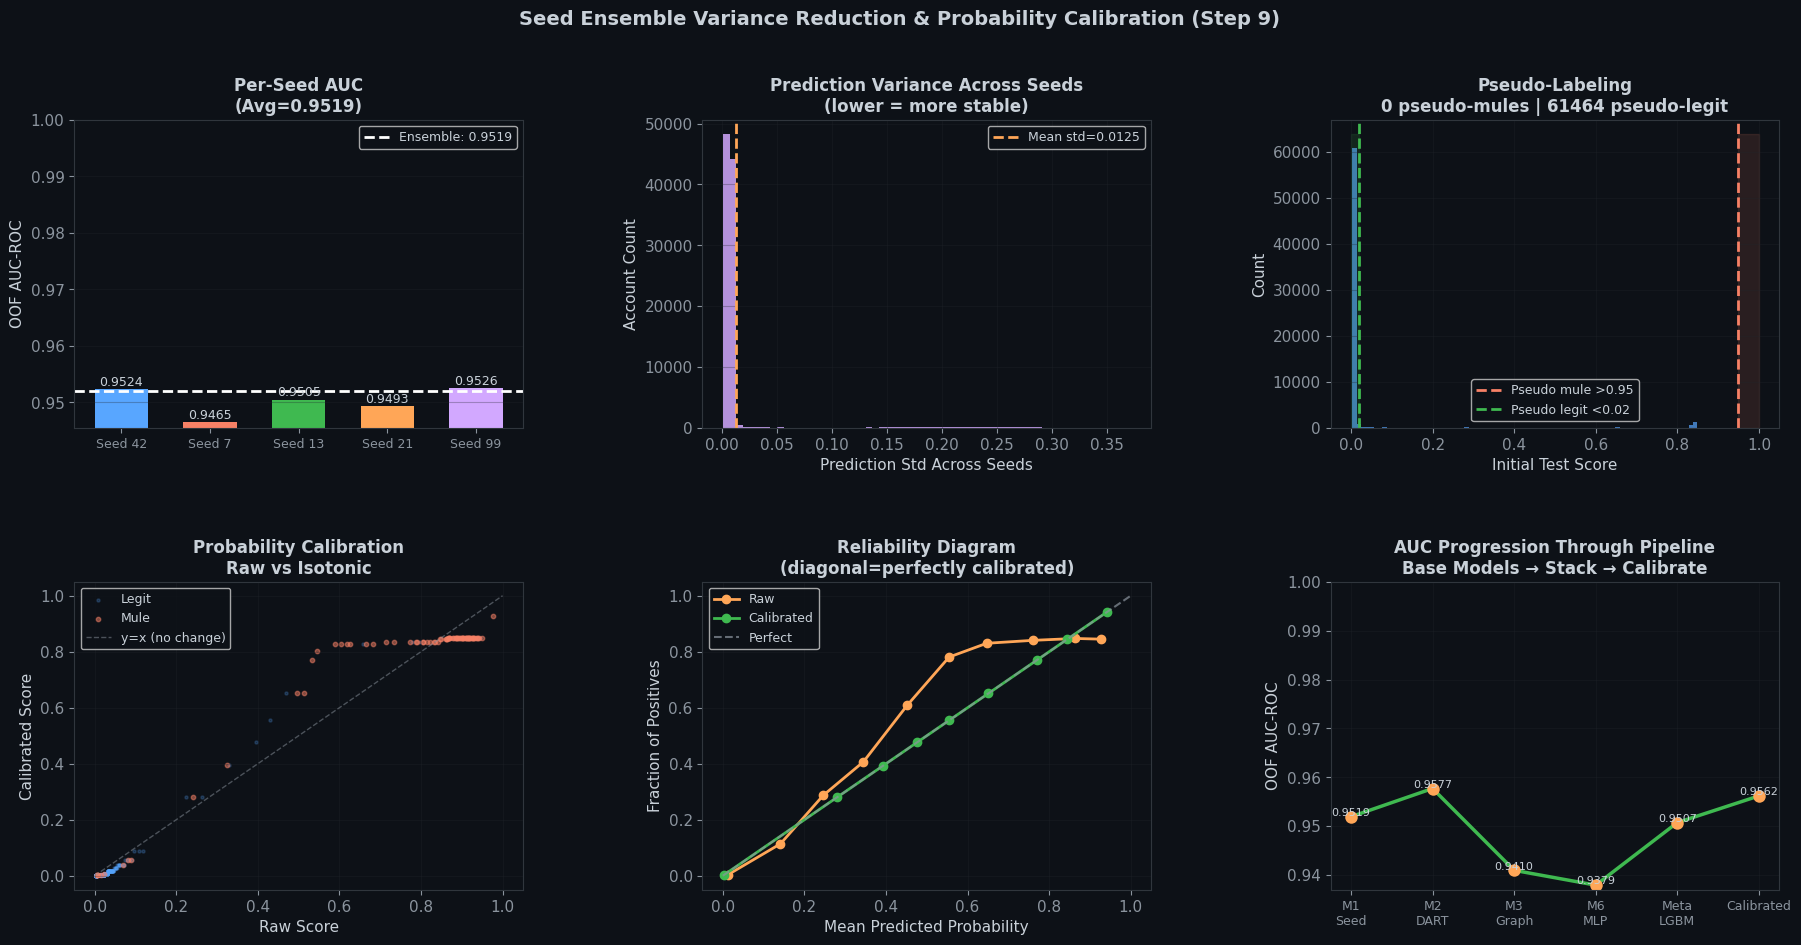

VIZ D saved: viz_D_ensemble_calibration.png


In [21]:

# ══════════════════════════════════════════════════════════════════
# VIZ D: SEED ENSEMBLE + CALIBRATION (Step 9)
# Requires: oof1_seeds, oof_final, oof_calibrated, oof_meta, yt
# ══════════════════════════════════════════════════════════════════
print("Generating ensemble and calibration visualizations...")

fig = plt.figure(figsize=(22,10), facecolor=DARK)
fig.suptitle('Seed Ensemble Variance Reduction & Probability Calibration (Step 9)',
             fontsize=14, fontweight='bold', color=WHITE, y=0.99)
gs_d = gridspec.GridSpec(2,3, figure=fig, hspace=0.5, wspace=0.4)

# Per-seed AUC
ax = fig.add_subplot(gs_d[0,0])
if hasattr(oof1_seeds,'shape') and oof1_seeds.ndim==2:
    _seed_aucs = [roc_auc_score(yt, oof1_seeds[:,i]) for i in range(oof1_seeds.shape[1])]
    _avg_auc   = roc_auc_score(yt, oof1)
    ax.bar([f'Seed {s}' for s in SEED_ENSEMBLE], _seed_aucs,
           color=PALETTE[:len(_seed_aucs)], edgecolor='none', width=0.6)
    ax.axhline(_avg_auc, color='white', linestyle='--', linewidth=2,
               label=f'Ensemble: {_avg_auc:.4f}')
    for i,v in enumerate(_seed_aucs):
        ax.text(i, v+0.0001, f'{v:.4f}', ha='center', va='bottom', fontsize=9, color=WHITE)
    ax.set_ylim(min(_seed_aucs)*0.999, 1.0)
    ax.set_ylabel('OOF AUC-ROC', color=WHITE)
    ax.set_title(f'Per-Seed AUC\n(Avg={_avg_auc:.4f})', color=WHITE)
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', labelsize=9)
else:
    ax.text(0.5,0.5,'oof1_seeds\nnot available',transform=ax.transAxes,
            ha='center',va='center',color=GRAY,fontsize=10)
    ax.set_title('Per-Seed AUC', color=WHITE)

# Seed variance
ax = fig.add_subplot(gs_d[0,1])
if hasattr(oof1_seeds,'shape') and oof1_seeds.ndim==2:
    _pred_std = oof1_seeds.std(axis=1)
    ax.hist(_pred_std, bins=60, color=PURPLE, edgecolor='none', alpha=0.85)
    ax.axvline(_pred_std.mean(), color=ORANGE, linestyle='--', linewidth=2,
               label=f'Mean std={_pred_std.mean():.4f}')
    ax.set_xlabel('Prediction Std Across Seeds', color=WHITE)
    ax.set_ylabel('Account Count', color=WHITE)
    ax.set_title('Prediction Variance Across Seeds\n(lower = more stable)', color=WHITE)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
else:
    ax.text(0.5,0.5,'Not available',transform=ax.transAxes,ha='center',va='center',color=GRAY)

# Pseudo-labeling
ax = fig.add_subplot(gs_d[0,2])
_pml = tpred_init > PSEUDO_HIGH; _pll = tpred_init < PSEUDO_LOW
_npm = _pml.sum(); _npl = _pll.sum()
ax.hist(tpred_init, bins=80, color=BLUE, edgecolor='none', alpha=0.7)
ax.axvline(PSEUDO_HIGH, color=RED,   linestyle='--', linewidth=2, label=f'Pseudo mule >{PSEUDO_HIGH}')
ax.axvline(PSEUDO_LOW,  color=GREEN, linestyle='--', linewidth=2, label=f'Pseudo legit <{PSEUDO_LOW}')
_ylim = ax.get_ylim()[1]
ax.fill_between([PSEUDO_HIGH,1.0],[0,0],[_ylim,_ylim],alpha=0.12,color=RED)
ax.fill_between([0,PSEUDO_LOW],[0,0],[_ylim,_ylim],alpha=0.12,color=GREEN)
ax.set_xlabel('Initial Test Score', color=WHITE); ax.set_ylabel('Count', color=WHITE)
ax.set_title(f'Pseudo-Labeling\n{_npm} pseudo-mules | {_npl} pseudo-legit', color=WHITE)
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Raw vs calibrated scatter
ax = fig.add_subplot(gs_d[1,0])
_s = np.random.choice(len(oof_final), min(3000,len(oof_final)), replace=False)
ax.scatter(oof_final[_s][yt[_s]==0], oof_calibrated[_s][yt[_s]==0],
           c=BLUE, alpha=0.2, s=5, label='Legit')
ax.scatter(oof_final[_s][yt[_s]==1], oof_calibrated[_s][yt[_s]==1],
           c=RED, alpha=0.5, s=10, label='Mule')
ax.plot([0,1],[0,1],'--',color=GRAY,alpha=0.5,linewidth=1,label='y=x (no change)')
ax.set_xlabel('Raw Score', color=WHITE); ax.set_ylabel('Calibrated Score', color=WHITE)
ax.set_title('Probability Calibration\nRaw vs Isotonic', color=WHITE)
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Reliability diagram
ax = fig.add_subplot(gs_d[1,1])
from sklearn.calibration import calibration_curve
for scores, name, color in [(oof_final,'Raw',ORANGE),(oof_calibrated,'Calibrated',GREEN)]:
    try:
        fp, mp = calibration_curve(yt, scores, n_bins=10, strategy='uniform')
        ax.plot(mp, fp, 'o-', color=color, linewidth=2, markersize=6, label=name)
    except: pass
ax.plot([0,1],[0,1],'--',color=GRAY,linewidth=1.5,alpha=0.7,label='Perfect')
ax.set_xlabel('Mean Predicted Probability', color=WHITE)
ax.set_ylabel('Fraction of Positives', color=WHITE)
ax.set_title('Reliability Diagram\n(diagonal=perfectly calibrated)', color=WHITE)
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# AUC progression line
ax = fig.add_subplot(gs_d[1,2])
_mnms = ['M1\nSeed','M2\nDART','M3\nGraph','M6\nMLP','Meta\nLGBM','Calibrated']
_moofs = [oof1,oof2,oof3,oof6,oof_meta,oof_calibrated]
_maucs = [roc_auc_score(yt,o) for o in _moofs]
ax.plot(range(len(_mnms)), _maucs, 'o-',
        color=GREEN, linewidth=2.5, markersize=9,
        markerfacecolor=ORANGE, markeredgewidth=0)
for i,(m,v) in enumerate(zip(_mnms,_maucs)):
    ax.text(i, v+0.0002, f'{v:.4f}', ha='center', fontsize=8, color=WHITE)
ax.set_xticks(range(len(_mnms))); ax.set_xticklabels(_mnms, fontsize=9)
ax.set_ylabel('OOF AUC-ROC', color=WHITE)
ax.set_title('AUC Progression Through Pipeline\nBase Models → Stack → Calibrate', color=WHITE)
ax.set_ylim(min(_maucs)*0.999, 1.0); ax.grid(alpha=0.3)

plt.savefig(f'{OUTPUT}/viz_D_ensemble_calibration.png', dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()
print("VIZ D saved: viz_D_ensemble_calibration.png")


## Temporal Windows & Pattern Attribution

In [22]:
# PATTERN ATTRIBUTION REPORT
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*80)
print("PATTERN ATTRIBUTION REPORT")
print("="*80)
predicted_mules = tpred_calibrated >= bth
mule_scores_df  = pd.DataFrame({'account_id': tids, 'score': tpred_calibrated,
                                 'is_pred_mule': predicted_mules})
report_cols = [c for c in [
    'trp','ps49','pt','pngt','fast_passthru_n','g_mcm','g2_mcm','g3_mcm',
    'sal_anomaly','age_d','n','sa','branch_mule_rate','bc_max_shared_cp',
    'geo_spread','n_unique_ips','ci_ratio','gap_dormancy_max','susp_score_norm',
    'mcc_zscore_max','mcc_n_outlier','nri_graph','bal_utilization',
    'g_cp_entropy','g_ring_max_shared','fan_in_out_ratio','burst_ratio_30d',
    'g_flow_ratio','reversal_rate','tod_entropy',
] if c in F.columns]
mule_scores_df = mule_scores_df.merge(
    F.loc[~tm, ['account_id'] + report_cols], on='account_id', how='left')
pm = mule_scores_df[mule_scores_df['is_pred_mule']]
print(f"\nPredicted mules: {len(pm):,} / {len(tids):,} ({len(pm)/len(tids)*100:.1f}%)")

patterns = [
    ('Structuring (near 50K)',    'ps49',              0.05,  False),
    ('Round amounts',             'trp',               0.30,  False),
    ('Rapid pass-through',        'pt',                0.80,  False),
    ('Night-time txns',           'pngt',              0.15,  False),
    ('Fast pass-thru (<24h)',     'fast_passthru_n',   1,     False),
    ('High graph mule score',     'g_mcm',             0.20,  False),
    ('2-hop mule exposure',       'g2_mcm',            0.10,  False),
    ('3-hop mule exposure',       'g3_mcm',            0.05,  False),
    ('Salary anomaly',            'sal_anomaly',       2.0,   False),
    ('New account',               'age_d',             365,   True),
    ('Branch collusion',          'bc_max_shared_cp',  3,     False),
    ('Dormancy then burst',       'gap_dormancy_max',  720,   False),
    ('MCC amount anomaly',        'mcc_zscore_max',    3,     False),
    ('Ring detection',            'g_ring_max_shared', 5,     False),
    ('Fan-in/out asymmetry',      'fan_in_out_ratio',  3,     False),
    ('Low CP entropy (few CPs)',  'g_cp_entropy',      1.5,   True),
    ('Temporal burst 30d',        'burst_ratio_30d',   2,     False),
    ('Net flow in (money sink)',  'g_flow_ratio',      0.6,   False),
    ('Reversal abuse',            'reversal_rate',     0.05,  False),
]
print("\nPattern prevalence among predicted mules:")
for name, col, thresh, reverse in patterns:
    if col in pm.columns and pm[col].notna().any():
        pct = (pm[col] < thresh if reverse else pm[col] > thresh).mean() * 100
        print(f"  {name:<35}: {pct:.1f}%")

# ══════════════════════════════════════════════════════════════════════════════
# SUBMISSION
# ══════════════════════════════════════════════════════════════════════════════


PATTERN ATTRIBUTION REPORT

Predicted mules: 1,948 / 64,062 (3.0%)

Pattern prevalence among predicted mules:
  Structuring (near 50K)             : 0.0%
  Round amounts                      : 5.1%
  Rapid pass-through                 : 36.0%
  Night-time txns                    : 32.6%
  Fast pass-thru (<24h)              : 98.9%
  High graph mule score              : 10.1%
  2-hop mule exposure                : 0.0%
  3-hop mule exposure                : 0.0%
  Salary anomaly                     : 91.6%
  New account                        : 21.1%
  Branch collusion                   : 95.2%
  Dormancy then burst                : 9.1%
  MCC amount anomaly                 : 98.1%
  Ring detection                     : 99.5%
  Fan-in/out asymmetry               : 0.4%
  Low CP entropy (few CPs)           : 0.0%
  Temporal burst 30d                 : 2.5%
  Net flow in (money sink)           : 0.0%
  Reversal abuse                     : 0.0%


### 📊 Visualization 5: Pattern Attribution & Temporal Analysis

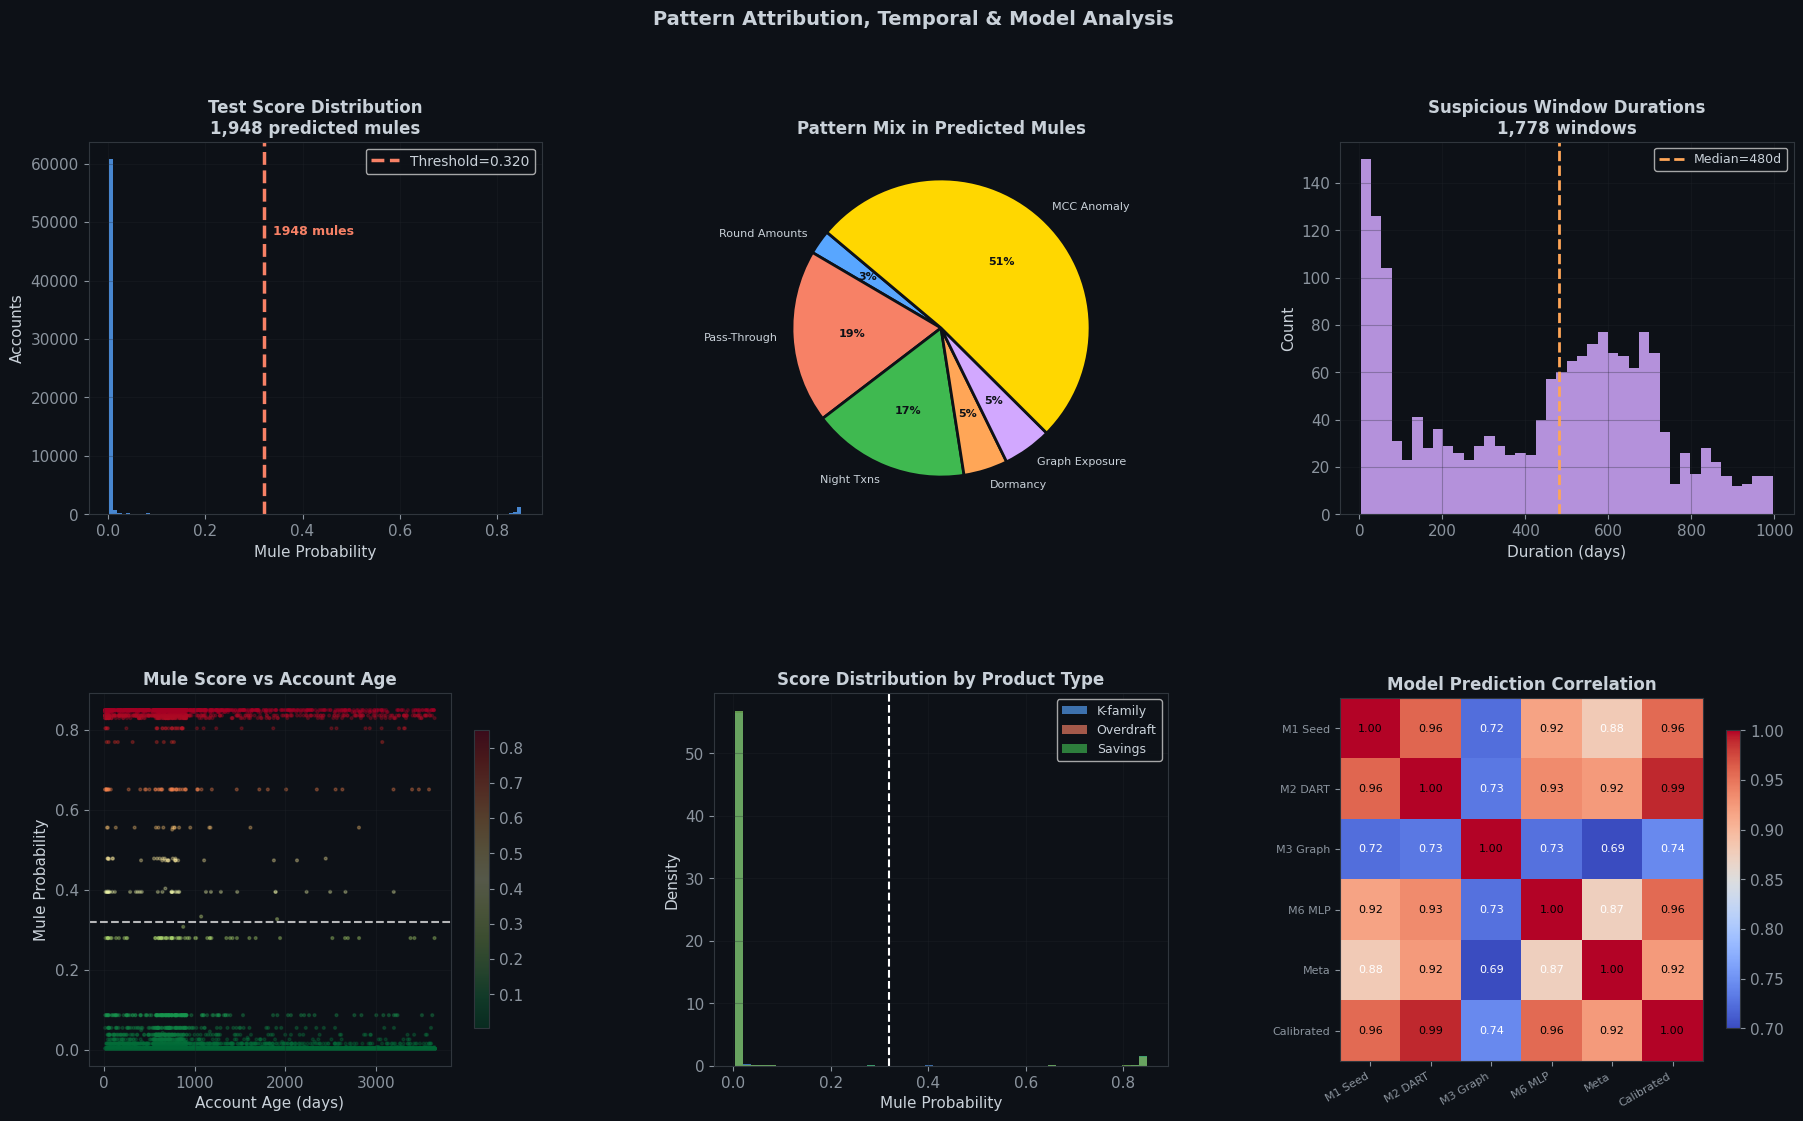

VIZ 5 saved: viz_05_pattern_temporal.png


In [23]:
# ══════════════════════════════════════════════════════════════════
# VIZ 5: PATTERN ATTRIBUTION + MODEL AGREEMENT
# ══════════════════════════════════════════════════════════════════
fig=plt.figure(figsize=(22,12),facecolor=DARK)
fig.suptitle('Pattern Attribution, Temporal & Model Analysis',
             fontsize=14,fontweight='bold',color=WHITE,y=0.99)
gs5=gridspec.GridSpec(2,3,figure=fig,hspace=0.48,wspace=0.38)

# Prediction distribution
ax=fig.add_subplot(gs5[0,0])
ax.hist(tpred_calibrated,bins=100,color=BLUE,edgecolor='none',alpha=0.8)
ax.axvline(bth,color=RED,linestyle='--',linewidth=2.5,label=f'Threshold={bth:.3f}')
n_mp=(tpred_calibrated>=bth).sum()
ax.set_xlabel('Mule Probability',color=WHITE); ax.set_ylabel('Accounts',color=WHITE)
ax.set_title(f'Test Score Distribution\n{n_mp:,} predicted mules',color=WHITE)
ax.legend(fontsize=10); ax.grid(alpha=0.3)
ax.text(bth+0.02,ax.get_ylim()[1]*0.75,f'{n_mp} mules',color=RED,fontsize=9,fontweight='bold')

# Pattern pie
ax=fig.add_subplot(gs5[0,1])
pat_det={}
for nm,col,thr,rev in [
    ('Structuring','ps49',0.02,False),
    ('Round Amounts','trp',0.30,False),
    ('Pass-Through','pt',0.80,False),
    ('Night Txns','pngt',0.15,False),
    ('Fan-In/Out','fan_in_out_ratio',2.0,False),
    ('Dormancy','gap_dormancy_max',720,False),
    ('Graph Exposure','g_mcm',0.20,False),
    ('MCC Anomaly','mcc_zscore_max',3.0,False),
]:
    if col in pm.columns and pm[col].notna().any():
        pct=(pm[col]<thr if rev else pm[col]>thr).mean()*100
        if pct>5: pat_det[nm]=pct
if pat_det:
    wc=PALETTE[:len(pat_det)]
    wedges,texts,autotexts=ax.pie(list(pat_det.values()),labels=list(pat_det.keys()),
                                   colors=wc,autopct='%1.0f%%',startangle=140,
                                   wedgeprops={'edgecolor':DARK,'linewidth':2})
    for at in autotexts: at.set_color(DARK); at.set_fontsize(8); at.set_fontweight('bold')
    for t in texts: t.set_color(WHITE); t.set_fontsize(8)
ax.set_title('Pattern Mix in Predicted Mules',color=WHITE)

# Temporal windows duration
ax=fig.add_subplot(gs5[0,2])
wdurs=[]
for acct_id,win in list(windows.items()):
    s,e=win.get('s'),win.get('e')
    if s and e:
        try:
            dur=(pd.Timestamp(e)-pd.Timestamp(s)).days
            if 0<dur<1000: wdurs.append(dur)
        except: pass
if wdurs:
    ax.hist(wdurs,bins=40,color=PURPLE,edgecolor='none',alpha=0.85)
    ax.axvline(np.median(wdurs),color=ORANGE,linestyle='--',linewidth=2,
               label=f'Median={np.median(wdurs):.0f}d')
    ax.set_xlabel('Duration (days)',color=WHITE); ax.set_ylabel('Count',color=WHITE)
    ax.set_title(f'Suspicious Window Durations\n{len(wdurs):,} windows',color=WHITE)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
else:
    ax.text(0.5,0.5,'No windows\ngenerated',transform=ax.transAxes,
            ha='center',va='center',color=GRAY,fontsize=12)
    ax.set_title('Suspicious Windows',color=WHITE)

# Score vs account age
ax=fig.add_subplot(gs5[1,0])
if 'age_d' in F.columns:
    _tmp=F[F['account_id'].isin(test_accounts['account_id'])].merge(
        pd.DataFrame({'account_id':tids,'score':tpred_calibrated}),
        on='account_id',how='inner')
    if len(_tmp)>100:
        sc=ax.scatter(_tmp['age_d'].clip(0,4000),_tmp['score'],
                      c=_tmp['score'],cmap='RdYlGn_r',alpha=0.3,s=4)
        plt.colorbar(sc,ax=ax,shrink=0.8)
        ax.axhline(bth,color='white',linestyle='--',linewidth=1.5,alpha=0.7)
        ax.set_xlabel('Account Age (days)',color=WHITE)
        ax.set_ylabel('Mule Probability',color=WHITE)
        ax.set_title('Mule Score vs Account Age',color=WHITE); ax.grid(alpha=0.3)

# Mule score by product family
ax=fig.add_subplot(gs5[1,1])
if 'product_family' in accounts.columns:
    _ts=pd.DataFrame({'account_id':tids,'score':tpred_calibrated})
    _ts=_ts.merge(accounts[['account_id','product_family']],on='account_id',how='left')
    _ts['product_family']=_ts['product_family'].map(
        {'S':'Savings','K':'K-family','O':'Overdraft'}).fillna('Unknown')
    for i,(nm,grp) in enumerate(_ts.groupby('product_family')):
        ax.hist(grp['score'],bins=50,alpha=0.65,color=PALETTE[i],
                label=nm,density=True)
    ax.axvline(bth,color='white',linestyle='--',linewidth=1.5)
    ax.set_xlabel('Mule Probability',color=WHITE); ax.set_ylabel('Density',color=WHITE)
    ax.set_title('Score Distribution by Product Type',color=WHITE)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Model correlation heatmap
ax=fig.add_subplot(gs5[1,2])
oof_arr=np.column_stack([oof1,oof2,oof3,oof6,oof_meta,oof_calibrated])
corr_m=np.corrcoef(oof_arr.T)
mlbls=['M1 Seed','M2 DART','M3 Graph','M6 MLP','Meta','Calibrated']
im=ax.imshow(corr_m,cmap='coolwarm',vmin=0.7,vmax=1.0)
ax.set_xticks(range(len(mlbls))); ax.set_xticklabels(mlbls,rotation=30,ha='right',fontsize=8)
ax.set_yticks(range(len(mlbls))); ax.set_yticklabels(mlbls,fontsize=8)
for i in range(len(mlbls)):
    for j in range(len(mlbls)):
        ax.text(j,i,f'{corr_m[i,j]:.2f}',ha='center',va='center',
                fontsize=8,color='black' if corr_m[i,j]>0.9 else 'white')
plt.colorbar(im,ax=ax,shrink=0.8)
ax.set_title('Model Prediction Correlation',color=WHITE)

plt.savefig(f'{OUTPUT}/viz_05_pattern_temporal.png',dpi=130,bbox_inches='tight',facecolor=DARK)
plt.show()
print("VIZ 5 saved: viz_05_pattern_temporal.png")


### 📊 Visualization E: Temporal Deep Dive (Steps 5 & 10)

Generating temporal deep-dive visualizations...


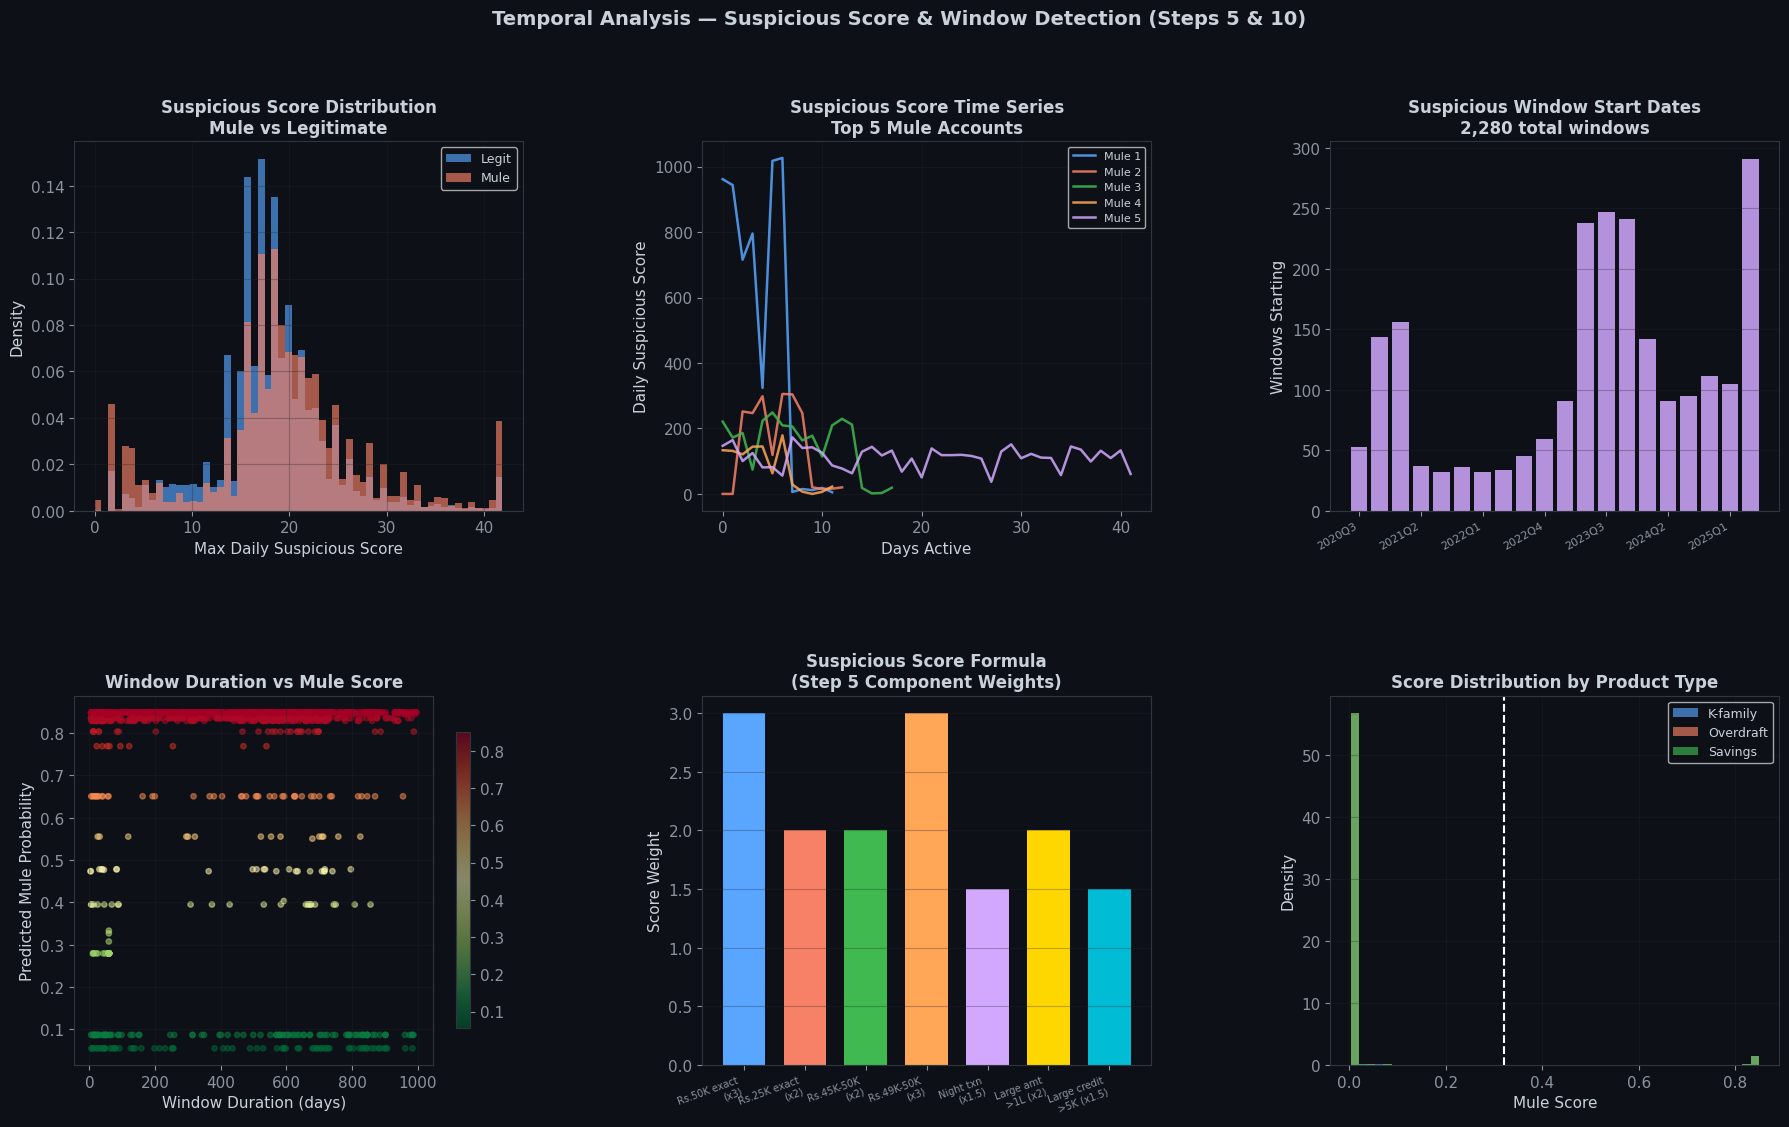

VIZ E saved: viz_E_temporal_deep.png


In [24]:

# ══════════════════════════════════════════════════════════════════
# VIZ E: TEMPORAL DEEP DIVE (Steps 5 & 10)
# Requires: daily_susp_df, windows, train_labels, tpred_calibrated, tids
# ══════════════════════════════════════════════════════════════════
print("Generating temporal deep-dive visualizations...")

fig = plt.figure(figsize=(22,12), facecolor=DARK)
fig.suptitle('Temporal Analysis — Suspicious Score & Window Detection (Steps 5 & 10)',
             fontsize=14, fontweight='bold', color=WHITE, y=0.99)
gs_e = gridspec.GridSpec(2,3, figure=fig, hspace=0.5, wspace=0.4)

_mule_ids_set = set(train_labels[train_labels['is_mule']==1]['account_id'])

# Suspicious score: mule vs legit
ax = fig.add_subplot(gs_e[0,0])
if len(daily_susp_df) > 0:
    _acct_max = daily_susp_df.groupby('account_id')['susp'].max()
    _ms = _acct_max[_acct_max.index.isin(_mule_ids_set)]
    _ls = _acct_max[~_acct_max.index.isin(_mule_ids_set)]
    _hi = np.percentile(_acct_max, 99)
    ax.hist(_ls.clip(0,_hi), bins=60, alpha=0.65, color=BLUE, label='Legit', density=True)
    ax.hist(_ms.clip(0,_hi), bins=60, alpha=0.65, color=RED,  label='Mule',  density=True)
    ax.set_xlabel('Max Daily Suspicious Score', color=WHITE)
    ax.set_ylabel('Density', color=WHITE)
    ax.set_title('Suspicious Score Distribution\nMule vs Legitimate', color=WHITE)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
else:
    ax.text(0.5,0.5,'daily_susp_df\nnot available',transform=ax.transAxes,
            ha='center',va='center',color=GRAY,fontsize=10)

# Time series for top mule accounts
ax = fig.add_subplot(gs_e[0,1])
if len(daily_susp_df) > 0 and len(_mule_ids_set) > 0:
    _acct_max2 = daily_susp_df.groupby('account_id')['susp'].max()
    _mids_in_daily = [a for a in _mule_ids_set if a in _acct_max2.index]
    if _mids_in_daily:
        _top5 = _acct_max2[_mids_in_daily].nlargest(5).index
        for i, acct in enumerate(_top5):
            _ad = daily_susp_df[daily_susp_df['account_id']==acct].sort_values('date')
            if len(_ad)>3:
                ax.plot(range(len(_ad)), _ad['susp'], linewidth=1.8,
                        alpha=0.85, color=PALETTE[i], label=f'Mule {i+1}')
        ax.set_xlabel('Days Active', color=WHITE); ax.set_ylabel('Daily Suspicious Score', color=WHITE)
        ax.set_title('Suspicious Score Time Series\nTop 5 Mule Accounts', color=WHITE)
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
else:
    ax.text(0.5,0.5,'No time series\navailable',transform=ax.transAxes,
            ha='center',va='center',color=GRAY)

# Window start dates
ax = fig.add_subplot(gs_e[0,2])
_wstarts = []
for acct_id, win in windows.items():
    s = win.get('s')
    if s:
        try: _wstarts.append(pd.Timestamp(s))
        except: pass
if _wstarts:
    _ws_s = pd.Series(_wstarts)
    _mw = _ws_s.dt.to_period('Q').value_counts().sort_index()
    ax.bar(range(len(_mw)), _mw.values, color=PURPLE, edgecolor='none', alpha=0.85)
    _ts = max(1, len(_mw)//6)
    ax.set_xticks(range(0,len(_mw),_ts))
    ax.set_xticklabels([str(_mw.index[i]) for i in range(0,len(_mw),_ts)],
                        rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Windows Starting', color=WHITE)
    ax.set_title(f'Suspicious Window Start Dates\n{len(_wstarts):,} total windows', color=WHITE)
    ax.grid(axis='y', alpha=0.3)

# Window duration vs score
ax = fig.add_subplot(gs_e[1,0])
_ws_df = pd.DataFrame({'account_id':tids,'score':tpred_calibrated})
_wdl = []
for acct_id, win in windows.items():
    s,e = win.get('s'),win.get('e')
    if s and e:
        try:
            dur=(pd.Timestamp(e)-pd.Timestamp(s)).days
            if 0<dur<1000:
                sc_row = _ws_df[_ws_df['account_id']==acct_id]['score']
                if len(sc_row)>0:
                    _wdl.append({'duration':dur,'score':float(sc_row.iloc[0])})
        except: pass
if _wdl:
    _wdd = pd.DataFrame(_wdl)
    sc = ax.scatter(_wdd['duration'], _wdd['score'], c=_wdd['score'],
                    cmap='RdYlGn_r', alpha=0.5, s=15)
    plt.colorbar(sc, ax=ax, shrink=0.8)
    ax.set_xlabel('Window Duration (days)', color=WHITE)
    ax.set_ylabel('Predicted Mule Probability', color=WHITE)
    ax.set_title('Window Duration vs Mule Score', color=WHITE)
    ax.grid(alpha=0.3)

# Suspicious score formula components
ax = fig.add_subplot(gs_e[1,1])
_comps = {
    'Rs.50K exact\n(x3)': 3, 'Rs.25K exact\n(x2)': 2,
    'Rs.45K-50K\n(x2)': 2, 'Rs.49K-50K\n(x3)': 3,
    'Night txn\n(x1.5)': 1.5, 'Large amt\n>1L (x2)': 2,
    'Large credit\n>5K (x1.5)': 1.5,
}
ax.bar(range(len(_comps)), list(_comps.values()),
       color=PALETTE[:len(_comps)], edgecolor='none', width=0.7)
ax.set_xticks(range(len(_comps)))
ax.set_xticklabels(list(_comps.keys()), fontsize=7, rotation=20, ha='right')
ax.set_ylabel('Score Weight', color=WHITE)
ax.set_title('Suspicious Score Formula\n(Step 5 Component Weights)', color=WHITE)
ax.grid(axis='y', alpha=0.3)

# Score vs product family
ax = fig.add_subplot(gs_e[1,2])
if 'product_family' in accounts.columns:
    _ts_pf = pd.DataFrame({'account_id':tids,'score':tpred_calibrated})
    _ts_pf = _ts_pf.merge(accounts[['account_id','product_family']], on='account_id', how='left')
    _ts_pf['pf'] = _ts_pf['product_family'].map({'S':'Savings','K':'K-family','O':'Overdraft'}).fillna('Unknown')
    for i,(nm,grp) in enumerate(_ts_pf.groupby('pf')):
        ax.hist(grp['score'], bins=50, alpha=0.65, color=PALETTE[i], label=nm, density=True)
    ax.axvline(bth, color='white', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Mule Score', color=WHITE); ax.set_ylabel('Density', color=WHITE)
    ax.set_title('Score Distribution by Product Type', color=WHITE)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.savefig(f'{OUTPUT}/viz_E_temporal_deep.png', dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()
print("VIZ E saved: viz_E_temporal_deep.png")


## Submission Generation

In [26]:
sub = pd.DataFrame({'account_id': tids, 'is_mule': tpred_calibrated})
sub['suspicious_start'] = sub['account_id'].map(lambda x: windows.get(x, {}).get('s', ''))
sub['suspicious_end']   = sub['account_id'].map(lambda x: windows.get(x, {}).get('e', ''))

model_aucs = {
    'M1_seed_ens': roc_auc_score(yt, oof1),
    'M2_DART':     roc_auc_score(yt, oof2),
    'M3_graph':    roc_auc_score(yt, oof3),
    'M4_XGB':      roc_auc_score(yt, oof4) if HAS_XGB else 'N/A',
    'M5_CatBoost': roc_auc_score(yt, oof5) if HAS_CATBOOST else 'N/A',
    'M6_MLP':      roc_auc_score(yt, oof6),
    'meta_lgbm':   roc_auc_score(yt, oof_meta),
    'calibrated':  roc_auc_score(yt, oof_calibrated),
}
print(f"\n{'='*80}")
print("FINAL SUBMISSION STATS")
print(f"{'='*80}")
print(f"Total test accounts  : {len(sub):,}")
print(f"Predicted mules      : {predicted_mules.sum():,} ({predicted_mules.mean()*100:.1f}%)")
print(f"Windows provided     : {len(windows):,}")
for k, v in model_aucs.items():
    if v != 'N/A': print(f"  {k:<20}: {v:.6f}")
    else:          print(f"  {k:<20}: N/A")
print(f"OOF F1 @ {bth:.3f}       : {bf1:.6f}")
print(f"Total runtime        : {time.time()-t0:.0f}s")
print(f"{'='*80}")

sub.to_csv(f'{OUTPUT}/submission.csv', index=False)
print(f"\nSaved → {OUTPUT}/submission.csv")


FINAL SUBMISSION STATS
Total test accounts  : 64,062
Predicted mules      : 1,948 (3.0%)
Windows provided     : 2,280
  M1_seed_ens         : 0.951938
  M2_DART             : 0.957709
  M3_graph            : 0.940977
  M4_XGB              : 0.947927
  M5_CatBoost         : 0.946665
  M6_MLP              : 0.937947
  meta_lgbm           : 0.950741
  calibrated          : 0.956194
OOF F1 @ 0.320       : 0.843609
Total runtime        : 13420s

Saved → /kaggle/working/submission.csv
